In [ ]:
# ============================================================
# Task 1
# ============================================================

In [ ]:
import math
import numpy as np

# ============================================================
# (i) Heat pipe design + evaporator structure parameters
# ============================================================
Dp = 0.015      # m
Levap = 0.025   # m
Ladiab = 0.30   # m
Lcond = 0.025   # m

Leff = Ladiab + 0.5 * Levap + 0.5 * Lcond  # m

tw = 0.0025     # m (wick thickness; multiple layers - mesh)
UA_e = 10.8     # W/K evaporator conductance

Aw = (math.pi / 4.0) * (Dp**2 - (Dp - 2.0 * tw)**2)  # wick cross-sectional area, m^2
Dv = Dp - 2.0 * tw                                   # vapor core diameter, m
Av = (math.pi / 4.0) * (Dv**2)                        # vapor core area, m^2

rp_min = 0.000063   # m minimum pore radius
kappa = 1.94e-10    # m^2 permeability
theta_deg = 10.0    # degrees
theta_rad = math.radians(theta_deg)
re_min = rp_min / math.cos(theta_rad)  # m

# ============================================================
# (ii) Condenser design + operating parameters
# ============================================================
Tf_cond_in = 15.5 + 273.0  # K
q_dot = 250.0              # W
m_dot_c = 0.0080           # kg/s
eps_c = 0.6                # condenser heat exchanger effectiveness
cp_f = 4180.0              # J/(kg*K)

# ============================================================
# (iii) Determine T2, then compute P2 = Psat(T2)
# ============================================================
T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)  # K

# Given correlation: Psat(T) = exp(C0 + C1/T)
C0 = 25.73
C1 = -5266.0
P2 = math.exp(C0 + C1 / T2)  # units per correlation (treat as Pa in this assignment context)

# ============================================================
# (iv) Lagrange interpolation in pressure-space using anchors
#     Anchors are Psat at 15/30/45/60 C (given) and saturated
#     properties at those temperatures (from your table page).
# ============================================================

#for water, set ideal gas constant R and critical temp to
R = 461.5 #J/kgK
Tc = 647.3 #K

# Psat anchor points (Pa) at 15, 30, 45, 60 °C (given by prof)
PA = 1.71e3
PB = 4.25e3
PC = 9.59e3
PD = 19.95e3

# ---- Saturated properties at 15/30/45/60 °C from the table ----
# Densities (kg/m^3): computed as 1/(vapor specific volume) from table
# Liquid density from table
rhol15, rhol30, rhol45, rhol60 = 999.1, 995.6, 990.2, 983.2

# Vapor specific volumes from table (m^3/kg): 77.875, 32.878, 15.252, 7.6672
# Vapor densities = 1/v (kg/m^3)
rhov15 = 1.0 / 77.875
rhov30 = 1.0 / 32.878
rhov45 = 1.0 / 15.252
rhov60 = 1.0 / 7.6672

# Viscosities from table are in μPa·s -> convert to Pa·s (multiply by 1e-6)
mul15, mul30, mul45, mul60 = 1137.6e-6, 797.4e-6, 596.1e-6, 466.4e-6
muv15, muv30, muv45, muv60 = 9.59e-6,   10.01e-6,  10.46e-6,  10.93e-6

# Surface tension from table is in mN/m -> convert to N/m (divide by 1000)
sig15, sig30, sig45, sig60 = 73.49e-3, 71.19e-3, 68.78e-3, 66.24e-3

# Latent heat h_lv = h_g - h_f using table enthalpies (kJ/kg) -> convert to J/kg
# 15C: hf=62.98,  hg=2528.33
# 30C: hf=125.73, hg=2555.55
# 45C: hf=188.43, hg=2582.43
# 60C: hf=251.18, hg=2608.83
hlv15 = (2528.33 - 62.98) * 1e3
hlv30 = (2555.55 - 125.73) * 1e3
hlv45 = (2582.43 - 188.43) * 1e3
hlv60 = (2608.83 - 251.18) * 1e3

# ---- Lagrange weights (exactly as professor wrote) ----
WA = (P2 - PB) * (P2 - PC) * (P2 - PD) / ((PA - PB) * (PA - PC) * (PA - PD))
WB = (P2 - PA) * (P2 - PC) * (P2 - PD) / ((PB - PA) * (PB - PC) * (PB - PD))
WC = (P2 - PA) * (P2 - PB) * (P2 - PD) / ((PC - PA) * (PC - PB) * (PC - PD))
WD = (P2 - PA) * (P2 - PB) * (P2 - PC) / ((PD - PA) * (PD - PB) * (PD - PC))

# ---- Interpolated saturated properties at P2 ----
rhov = WA * rhov15 + WB * rhov30 + WC * rhov45 + WD * rhov60
rhol = WA * rhol15 + WB * rhol30 + WC * rhol45 + WD * rhol60
muv  = WA * muv15  + WB * muv30  + WC * muv45  + WD * muv60
mul  = WA * mul15  + WB * mul30  + WC * mul45  + WD * mul60
sig  = WA * sig15  + WB * sig30  + WC * sig45  + WD * sig60
hlv  = WA * hlv15  + WB * hlv30  + WC * hlv45  + WD * hlv60

# ============================================================
# Print results
# ============================================================
print("=== (i) Geometry / Wick ===")
print(f"Leff   = {Leff:.6f} m")
print(f"Aw     = {Aw:.8e} m^2")
print(f"Dv     = {Dv:.6f} m")
print(f"Av     = {Av:.8e} m^2")
print(f"re_min = {re_min:.8e} m")

print("\n=== (iii) Condenser end state ===")
print(f"T2 = {T2:.6f} K")
print(f"P2 = {P2:.6e} (per Psat correlation)")

print("\n=== (iv) Lagrange weights ===")
print(f"WA, WB, WC, WD = {WA:.6g}, {WB:.6g}, {WC:.6g}, {WD:.6g}")
print(f"Sum weights     = {(WA+WB+WC+WD):.6g}")

print("\n=== (iv) Saturated properties at P2 (interpolated) ===")
print(f"rhov = {rhov:.6g} kg/m^3")
print(f"rhol = {rhol:.6g} kg/m^3")
print(f"muv  = {muv:.6g} Pa·s")
print(f"mul  = {mul:.6g} Pa·s")
print(f"sig  = {sig:.6g} N/m")
print(f"hlv  = {hlv:.6g} J/kg")

# ============================================================
# (v) Vapor-flow pressure drop and P1
# ============================================================

# --- sanity checks (avoid silent crashes / nonsense) ---
if hlv <= 0:
    raise ValueError(f"hlv must be > 0 (J/kg). Got {hlv}.")
if rhov <= 0:
    raise ValueError(f"rhov must be > 0 (kg/m^3). Got {rhov}.")
if Av <= 0 or Dv <= 0:
    raise ValueError(f"Av and Dv must be > 0. Got Av={Av}, Dv={Dv}.")
if muv <= 0:
    raise ValueError(f"muv must be > 0 (Pa·s). Got {muv}.")
if Leff <= 0:
    raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

# Mass flow rate of vapor (kg/s)
m_dot_v = q_dot / hlv

# Vapor average velocity (m/s)
Vv = m_dot_v / (rhov * Av)

# Vapor Reynolds number (-)
Re_v = (rhov * Vv * Dv) / muv

# Fanning friction factor (laminar) (-)
fv = 16.0 / Re_v

# Vapor pressure rise from condenser end (P2) to evaporator end (P1) due to flow (Pa)
deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)

# Pressure at evaporator end (Pa)
P1 = P2 + deltaP_v

print("\n=== (v) Vapor flow / pressure drop ===")
print(f"m_dot_v   = {m_dot_v:.6g} kg/s")
print(f"Vv        = {Vv:.6g} m/s")
print(f"Re_v      = {Re_v:.6g} (-)")
print(f"f_v       = {fv:.6g} (-)")
print(f"deltaP_v  = {deltaP_v:.6g} Pa")
print(f"P1        = {P1:.6g} Pa")

# ============================================================
# (vi) Liquid flow pressure drop in porous wick (Darcy) and
#      pressure difference across curved interface in evaporator
# ============================================================

# --- sanity checks ---
if mul <= 0:
    raise ValueError(f"mul must be > 0 (Pa·s). Got {mul}.")
if kappa <= 0:
    raise ValueError(f"kappa must be > 0 (m^2). Got {kappa}.")
if rhol <= 0:
    raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
if Aw <= 0:
    raise ValueError(f"Aw must be > 0 (m^2). Got {Aw}.")
if m_dot_v <= 0:
    raise ValueError(f"m_dot_v must be > 0 (kg/s). Got {m_dot_v}.")
if Leff <= 0:
    raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

# Liquid flow pressure drop through wick (Pa)
# (m_dot is the same mass flow rate circulating: m_dot_v = q_dot/hlv)
deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)   # P3 - P4

# Total pressure difference from 1 to 4 (Pa)
# P2 = P3, so P1 - P4 = (P1 - P2) + (P3 - P4)
# From step (v): deltaP_v = P1 - P2
P1_minus_P4 = deltaP_v + deltaP_l

print("\n=== (vi) Wick (liquid) pressure drop + interface pressure difference ===")
print(f"deltaP_l (P3-P4) = {deltaP_l:.6g} Pa")
print(f"P1 - P4          = {P1_minus_P4:.6g} Pa")

# ============================================================
# (vii) Curved-interface equilibrium + saturation curve relation:

# Notes:
# - Uses sigma (N/m), re (m), rho_l (kg/m^3), R (J/kgK), Tc (K)
# - Requires P1 already computed in step (v), and deltaP_v/deltaP_l from (v)-(vi)
# ============================================================

# --- sanity checks ---
if sig <= 0:
    raise ValueError(f"sig must be > 0 (N/m). Got {sig}.")
if P1_minus_P4 <= 0:
    raise ValueError(f"P1_minus_P4 must be > 0 (Pa). Got {P1_minus_P4}.")
if rhol <= 0:
    raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
if R <= 0 or Tc <= 0:
    raise ValueError(f"R and Tc must be > 0. Got R={R}, Tc={Tc}.")

# 1) Interface radius from pressure difference (m)
re = (2.0 * sig) / P1_minus_P4

# Enforce constraint re > re_min
if re <= re_min:
    raise ValueError(
        f"Computed re={re:.3e} m is <= re_min={re_min:.3e} m. "
        "This violates the interface-radius constraint (capillary limit exceeded)."
    )

# 2) Compute T1 using provided rearranged relation
# Constants from handout (note C1 slightly different from earlier step)
C0_vii = 25.73
C1_vii = -5266.3  # K

P0 = math.exp(C0_vii)

# Dimensionless Nre (uses Tc as in handout)
Nre = (2.0 * sig) / (re * rhol * R * Tc)

# Compute T1
ln_P1_over_P0 = math.log(P1 / P0)
if ln_P1_over_P0 == 0:
    raise ValueError("ln(P1/P0) is zero; cannot compute T1.")

T1 = (C1_vii - Nre * Tc) / ln_P1_over_P0  # K

print("\n=== (vii) Curved-interface equilibrium ===")
print(f"re              = {re:.6e} m")
print(f"re_min          = {re_min:.6e} m")
print(f"Nre             = {Nre:.6e} (-)")
print(f"P0              = {P0:.6e} (same pressure units as P1)")
print(f"ln(P1/P0)       = {ln_P1_over_P0:.6e}")
print(f"T1              = {T1:.6f} K")

# ============================================================
# (viii) Chip temperature
# ============================================================

# --- sanity checks ---
if UA_e <= 0:
    raise ValueError(f"UA_e must be > 0 (W/K). Got {UA_e}.")
if q_dot < 0:
    raise ValueError(f"q_dot must be >= 0 (W). Got {q_dot}.")
if not math.isfinite(T1):
    raise ValueError(f"T1 must be finite. Got {T1}.")
if not math.isfinite(re):
    raise ValueError(f"re must be finite. Got {re}.")

T_chip = T1 + q_dot / UA_e  # K

# Physical realism checks for interface radius
capillary_ok = (re > re_min) and math.isfinite(re)

print("\n=== (viii) Chip temperature + realism check ===")
print(f"T_chip         = {T_chip:.6f} K")
print(f"T_chip (°C)    = {T_chip - 273.15:.3f} °C")
print(f"re             = {re:.6e} m")
print(f"re_min         = {re_min:.6e} m")
print(f"capillary_ok   = {capillary_ok}")

if not capillary_ok:
    raise ValueError(
        "Physically unrealistic operating point: re must be > re_min and finite. "
        f"Got re={re:.3e}, re_min={re_min:.3e}."
    )


=== (i) Geometry / Wick ===
Leff   = 0.325000 m
Aw     = 9.81747704e-05 m^2
Dv     = 0.010000 m
Av     = 7.85398163e-05 m^2
re_min = 6.39718765e-05 m

=== (iii) Condenser end state ===
T2 = 300.960128 K
P2 = 3.761848e+03 (per Psat correlation)

=== (iv) Lagrange weights ===
WA, WB, WC, WD = 0.126153, 0.909073, -0.0371938, 0.00196765
Sum weights     = 1

=== (iv) Saturated properties at P2 (interpolated) ===
rhov = 0.0270878 kg/m^3
rhol = 996.218 kg/m^3
muv  = 9.94209e-06 Pa·s
mul  = 0.000847153 Pa·s
sig  = 0.07156 N/m
hlv  = 2.43549e+06 J/kg

=== (v) Vapor flow / pressure drop ===
m_dot_v   = 0.000102649 kg/s
Vv        = 48.2491 m/s
Re_v      = 1314.58 (-)
f_v       = 0.0121712 (-)
deltaP_v  = 49.8884 Pa
P1        = 3811.74 Pa

=== (vi) Wick (liquid) pressure drop + interface pressure difference ===
deltaP_l (P3-P4) = 1489.51 Pa
P1 - P4          = 1539.4 Pa

=== (vii) Curved-interface equilibrium ===
re              = 9.297164e-05 m
re_min          = 6.397188e-05 m
Nre             = 5.

=== (i) Geometry / Wick ===
Leff   = 0.325000 m
Aw     = 9.81747704e-05 m^2
Dv     = 0.010000 m
Av     = 7.85398163e-05 m^2
re_min = 6.39718765e-05 m

=== (iii) Condenser end state ===
T2 = 290.992026 K
P2 = 2.065823e+03 (per Psat correlation)

=== (iv) Lagrange weights ===
WA, WB, WC, WD = 0.805065, 0.224847, -0.0318833, 0.00197105
Sum weights     = 1

=== (iv) Saturated properties at P2 (interpolated) ===
rhov = 0.0153434 kg/m^3
rhol = 998.565 kg/m^3
muv  = 9.65934e-06 Pa·s
mul  = 0.00107705 Pa·s
sig  = 0.0731087 N/m
hlv  = 2.45942e+06 J/kg

=== (v) Vapor flow / pressure drop ===
m_dot_v   = 2.033e-05 kg/s
Vv        = 16.8704 m/s
Re_v      = 267.978 (-)
f_v       = 0.0597064 (-)
deltaP_v  = 16.9475 Pa
P1        = 2082.77 Pa

=== (vi) Wick (liquid) pressure drop + interface pressure difference ===
deltaP_l (P3-P4) = 374.177 Pa
P1 - P4          = 391.125 Pa

=== (vii) Curved-interface equilibrium ===
re              = 3.738385e-04 m
re_min          = 6.397188e-05 m
Nre             = 1.

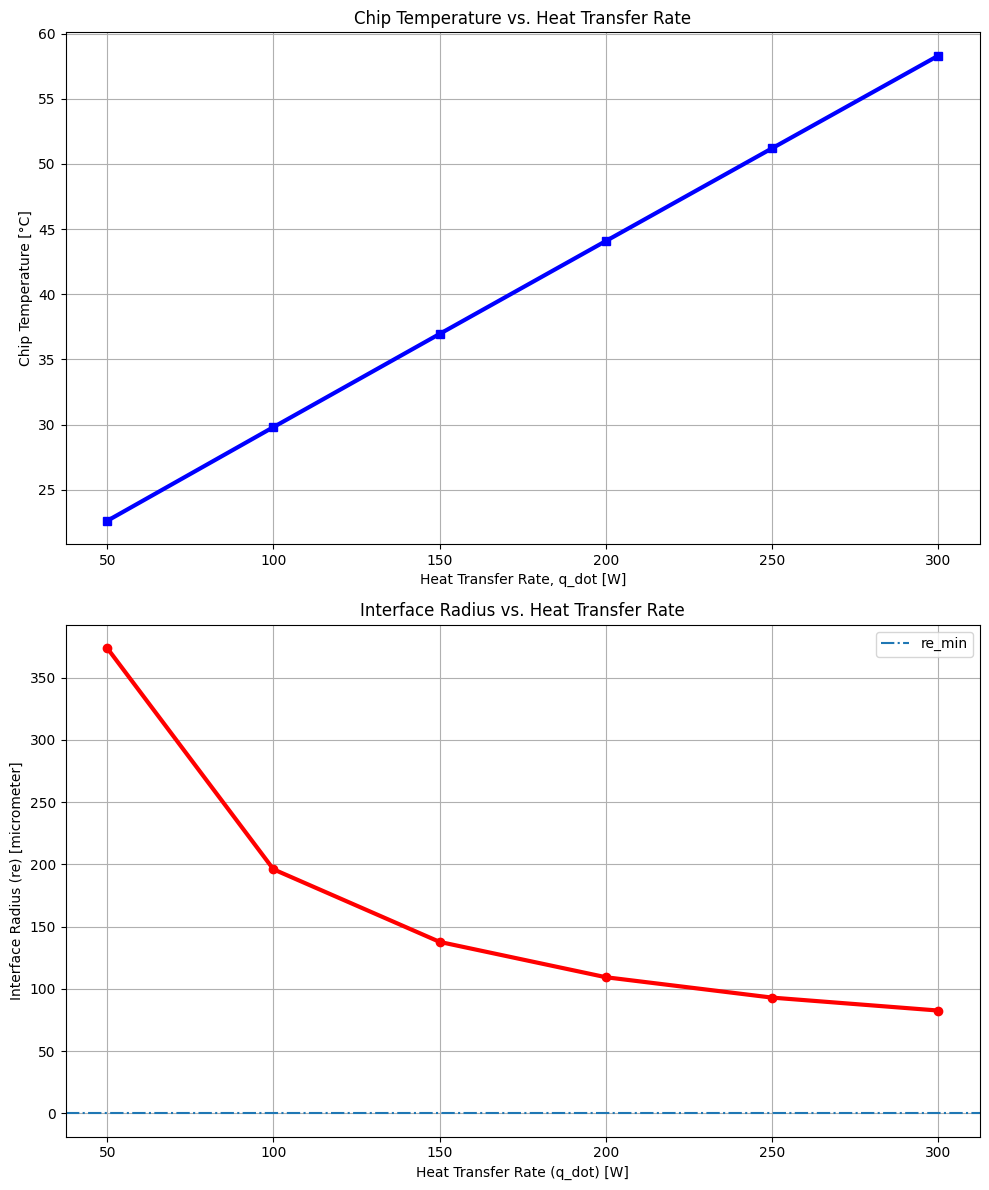

In [ ]:
# ============================================================
# Task 2 (a)
# ============================================================
import math
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# (i) Heat pipe design + evaporator structure parameters
# ============================================================
Dp = 0.015      # m
Levap = 0.025   # m
Ladiab = 0.30   # m
Lcond = 0.025   # m

Leff = Ladiab + 0.5 * Levap + 0.5 * Lcond  # m

tw = 0.0025     # m (wick thickness; multiple layers - mesh)
UA_e = 10.8     # W/K evaporator conductance

Aw = (math.pi / 4.0) * (Dp**2 - (Dp - 2.0 * tw)**2)  # wick cross-sectional area, m^2
Dv = Dp - 2.0 * tw                                   # vapor core diameter, m
Av = (math.pi / 4.0) * (Dv**2)                        # vapor core area, m^2

rp_min = 0.000063   # m minimum pore radius
kappa = 1.94e-10    # m^2 permeability
theta_deg = 10.0    # degrees
theta_rad = math.radians(theta_deg)
re_min = rp_min / math.cos(theta_rad)  # m

# ============================================================
# (ii) Condenser design + operating parameters
# ============================================================
Tf_cond_in = 15.5 + 273.0  # K
q_dot_array = [50.0, 100.0, 150.0, 200.0, 250.0, 300.0]      # W
m_dot_c = 0.0080           # kg/s
eps_c = 0.6                # condenser heat exchanger effectiveness
cp_f = 4180.0              # J/(kg*K)

T_chip_array = []       #initialize an array to store T_chip values in
re_array = []           #initialize an array to store re values

for q_dot in q_dot_array:
  # ============================================================
  # (iii) Determine T2, then compute P2 = Psat(T2)
  # ============================================================
  T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)  # K

  # Given correlation: Psat(T) = exp(C0 + C1/T)
  C0 = 25.73
  C1 = -5266.0
  P2 = math.exp(C0 + C1 / T2)  # units per correlation (treat as Pa in this assignment context)

  # ============================================================
  # (iv) Lagrange interpolation in pressure-space using anchors
  #     Anchors are Psat at 15/30/45/60 C (given) and saturated
  #     properties at those temperatures (from your table page).
  # ============================================================

  #for water, set ideal gas constant R and critical temp to
  R = 461.5 #J/kgK
  Tc = 647.3 #K

  # Psat anchor points (Pa) at 15, 30, 45, 60 °C (given by prof)
  PA = 1.71e3
  PB = 4.25e3
  PC = 9.59e3
  PD = 19.95e3

  # ---- Saturated properties at 15/30/45/60 °C from the table ----
  # Densities (kg/m^3): computed as 1/(vapor specific volume) from table
  # Liquid density from table
  rhol15, rhol30, rhol45, rhol60 = 999.1, 995.6, 990.2, 983.2

  # Vapor specific volumes from table (m^3/kg): 77.875, 32.878, 15.252, 7.6672
  # Vapor densities = 1/v (kg/m^3)
  rhov15 = 1.0 / 77.875
  rhov30 = 1.0 / 32.878
  rhov45 = 1.0 / 15.252
  rhov60 = 1.0 / 7.6672

  # Viscosities from table are in μPa·s -> convert to Pa·s (multiply by 1e-6)
  mul15, mul30, mul45, mul60 = 1137.6e-6, 797.4e-6, 596.1e-6, 466.4e-6
  muv15, muv30, muv45, muv60 = 9.59e-6,   10.01e-6,  10.46e-6,  10.93e-6

  # Surface tension from table is in mN/m -> convert to N/m (divide by 1000)
  sig15, sig30, sig45, sig60 = 73.49e-3, 71.19e-3, 68.78e-3, 66.24e-3

  # Latent heat h_lv = h_g - h_f using table enthalpies (kJ/kg) -> convert to J/kg
  # 15C: hf=62.98,  hg=2528.33
  # 30C: hf=125.73, hg=2555.55
  # 45C: hf=188.43, hg=2582.43
  # 60C: hf=251.18, hg=2608.83
  hlv15 = (2528.33 - 62.98) * 1e3
  hlv30 = (2555.55 - 125.73) * 1e3
  hlv45 = (2582.43 - 188.43) * 1e3
  hlv60 = (2608.83 - 251.18) * 1e3

  # ---- Lagrange weights (exactly as professor wrote) ----
  WA = (P2 - PB) * (P2 - PC) * (P2 - PD) / ((PA - PB) * (PA - PC) * (PA - PD))
  WB = (P2 - PA) * (P2 - PC) * (P2 - PD) / ((PB - PA) * (PB - PC) * (PB - PD))
  WC = (P2 - PA) * (P2 - PB) * (P2 - PD) / ((PC - PA) * (PC - PB) * (PC - PD))
  WD = (P2 - PA) * (P2 - PB) * (P2 - PC) / ((PD - PA) * (PD - PB) * (PD - PC))

  # ---- Interpolated saturated properties at P2 ----
  rhov = WA * rhov15 + WB * rhov30 + WC * rhov45 + WD * rhov60
  rhol = WA * rhol15 + WB * rhol30 + WC * rhol45 + WD * rhol60
  muv  = WA * muv15  + WB * muv30  + WC * muv45  + WD * muv60
  mul  = WA * mul15  + WB * mul30  + WC * mul45  + WD * mul60
  sig  = WA * sig15  + WB * sig30  + WC * sig45  + WD * sig60
  hlv  = WA * hlv15  + WB * hlv30  + WC * hlv45  + WD * hlv60

  # ============================================================
  # Print results
  # ============================================================
  print("=== (i) Geometry / Wick ===")
  print(f"Leff   = {Leff:.6f} m")
  print(f"Aw     = {Aw:.8e} m^2")
  print(f"Dv     = {Dv:.6f} m")
  print(f"Av     = {Av:.8e} m^2")
  print(f"re_min = {re_min:.8e} m")

  print("\n=== (iii) Condenser end state ===")
  print(f"T2 = {T2:.6f} K")
  print(f"P2 = {P2:.6e} (per Psat correlation)")

  print("\n=== (iv) Lagrange weights ===")
  print(f"WA, WB, WC, WD = {WA:.6g}, {WB:.6g}, {WC:.6g}, {WD:.6g}")
  print(f"Sum weights     = {(WA+WB+WC+WD):.6g}")

  print("\n=== (iv) Saturated properties at P2 (interpolated) ===")
  print(f"rhov = {rhov:.6g} kg/m^3")
  print(f"rhol = {rhol:.6g} kg/m^3")
  print(f"muv  = {muv:.6g} Pa·s")
  print(f"mul  = {mul:.6g} Pa·s")
  print(f"sig  = {sig:.6g} N/m")
  print(f"hlv  = {hlv:.6g} J/kg")

  # ============================================================
  # (v) Vapor-flow pressure drop and P1
  # ============================================================

  # --- sanity checks (avoid silent crashes / nonsense) ---
  if hlv <= 0:
      raise ValueError(f"hlv must be > 0 (J/kg). Got {hlv}.")
  if rhov <= 0:
      raise ValueError(f"rhov must be > 0 (kg/m^3). Got {rhov}.")
  if Av <= 0 or Dv <= 0:
      raise ValueError(f"Av and Dv must be > 0. Got Av={Av}, Dv={Dv}.")
  if muv <= 0:
      raise ValueError(f"muv must be > 0 (Pa·s). Got {muv}.")
  if Leff <= 0:
      raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

  # Mass flow rate of vapor (kg/s)
  m_dot_v = q_dot / hlv

  # Vapor average velocity (m/s)
  Vv = m_dot_v / (rhov * Av)

  # Vapor Reynolds number (-)
  Re_v = (rhov * Vv * Dv) / muv

  # Fanning friction factor (laminar) (-)
  fv = 16.0 / Re_v

  # Vapor pressure rise from condenser end (P2) to evaporator end (P1) due to flow (Pa)
  deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)

  # Pressure at evaporator end (Pa)
  P1 = P2 + deltaP_v

  print("\n=== (v) Vapor flow / pressure drop ===")
  print(f"m_dot_v   = {m_dot_v:.6g} kg/s")
  print(f"Vv        = {Vv:.6g} m/s")
  print(f"Re_v      = {Re_v:.6g} (-)")
  print(f"f_v       = {fv:.6g} (-)")
  print(f"deltaP_v  = {deltaP_v:.6g} Pa")
  print(f"P1        = {P1:.6g} Pa")

  # ============================================================
  # (vi) Liquid flow pressure drop in porous wick (Darcy) and
  #      pressure difference across curved interface in evaporator
  # ============================================================

  # --- sanity checks ---
  if mul <= 0:
      raise ValueError(f"mul must be > 0 (Pa·s). Got {mul}.")
  if kappa <= 0:
      raise ValueError(f"kappa must be > 0 (m^2). Got {kappa}.")
  if rhol <= 0:
      raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
  if Aw <= 0:
      raise ValueError(f"Aw must be > 0 (m^2). Got {Aw}.")
  if m_dot_v <= 0:
      raise ValueError(f"m_dot_v must be > 0 (kg/s). Got {m_dot_v}.")
  if Leff <= 0:
      raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

  # Liquid flow pressure drop through wick (Pa)
  # (m_dot is the same mass flow rate circulating: m_dot_v = q_dot/hlv)
  deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)   # P3 - P4

  # Total pressure difference from 1 to 4 (Pa)
  # P2 = P3, so P1 - P4 = (P1 - P2) + (P3 - P4)
  # From step (v): deltaP_v = P1 - P2
  P1_minus_P4 = deltaP_v + deltaP_l

  print("\n=== (vi) Wick (liquid) pressure drop + interface pressure difference ===")
  print(f"deltaP_l (P3-P4) = {deltaP_l:.6g} Pa")
  print(f"P1 - P4          = {P1_minus_P4:.6g} Pa")

  # ============================================================
  # (vii) Curved-interface equilibrium + saturation curve relation:

  # Notes:
  # - Uses sigma (N/m), re (m), rho_l (kg/m^3), R (J/kgK), Tc (K)
  # - Requires P1 already computed in step (v), and deltaP_v/deltaP_l from (v)-(vi)
  # ============================================================

  # --- sanity checks ---
  if sig <= 0:
      raise ValueError(f"sig must be > 0 (N/m). Got {sig}.")
  if P1_minus_P4 <= 0:
      raise ValueError(f"P1_minus_P4 must be > 0 (Pa). Got {P1_minus_P4}.")
  if rhol <= 0:
      raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
  if R <= 0 or Tc <= 0:
      raise ValueError(f"R and Tc must be > 0. Got R={R}, Tc={Tc}.")

  # 1) Interface radius from pressure difference (m)
  re = (2.0 * sig) / P1_minus_P4

  # Enforce constraint re > re_min
  if re <= re_min:
      raise ValueError(
          f"Computed re={re:.3e} m is <= re_min={re_min:.3e} m. "
          "This violates the interface-radius constraint (capillary limit exceeded)."
      )

  # 2) Compute T1 using provided rearranged relation
  # Constants from handout (note C1 slightly different from earlier step)
  C0_vii = 25.73
  C1_vii = -5266.3  # K

  P0 = math.exp(C0_vii)

  # Dimensionless Nre (uses Tc as in handout)
  Nre = (2.0 * sig) / (re * rhol * R * Tc)

  # Compute T1
  ln_P1_over_P0 = math.log(P1 / P0)
  if ln_P1_over_P0 == 0:
      raise ValueError("ln(P1/P0) is zero; cannot compute T1.")

  T1 = (C1_vii - Nre * Tc) / ln_P1_over_P0  # K

  print("\n=== (vii) Curved-interface equilibrium ===")
  print(f"re              = {re:.6e} m")
  print(f"re_min          = {re_min:.6e} m")
  print(f"Nre             = {Nre:.6e} (-)")
  print(f"P0              = {P0:.6e} (same pressure units as P1)")
  print(f"ln(P1/P0)       = {ln_P1_over_P0:.6e}")
  print(f"T1              = {T1:.6f} K")

  # ============================================================
  # (viii) Chip temperature
  # ============================================================

  # --- sanity checks ---
  if UA_e <= 0:
      raise ValueError(f"UA_e must be > 0 (W/K). Got {UA_e}.")
  if q_dot < 0:
      raise ValueError(f"q_dot must be >= 0 (W). Got {q_dot}.")
  if not math.isfinite(T1):
      raise ValueError(f"T1 must be finite. Got {T1}.")
  if not math.isfinite(re):
      raise ValueError(f"re must be finite. Got {re}.")

  T_chip = T1 + q_dot / UA_e  # K

  T_chip_array.append(T_chip) #append T_chip values from each iteration to array
  re_array.append(re) #append re values from each iteration to array

  # Physical realism checks for interface radius
  capillary_ok = (re > re_min) and math.isfinite(re)


  print("\n=== (viii) Chip temperature + realism check ===")
  print(f"q_dot = {q_dot} W")
  print(f"T_chip         = {T_chip:.6f} K")
  print(f"T_chip (°C)    = {T_chip - 273.15:.3f} °C")
  print(f"re             = {re:.6e} m")
  print(f"re_min         = {re_min:.6e} m")
  print(f"capillary_ok   = {capillary_ok}")

  if not capillary_ok:
      raise ValueError(
          "Physically unrealistic operating point: re must be > re_min and finite. "
          f"Got re={re:.3e}, re_min={re_min:.3e}."
      )

#print the arrays that store the values of T_chip and re for the different q_dot iteration values
print(f"\n T_chip_array is as follows: {[f'{T- 273.15:.3f}' for T in T_chip_array]}")
print(f"\n re is as follows in micrometers: {[f'{r*1e6:.3f}' for r in re_array]}")

#make plots for the relations between T_chip and q_dot and re and q_dot

#create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

#unit conversions for plotting
T_chip_array_C = []
for t in T_chip_array:
  T_chip_array_C.append(t - 273.15)

re_array_micro = []
for r in re_array:
  re_array_micro.append(r*1e6)

print (T_chip_array_C)
print(re_array_micro)
#plot 1: T_chip vs q_dot
ax1.plot(q_dot_array, T_chip_array_C, 'b-s', linewidth=3)
ax1.set_xlabel('Heat Transfer Rate, q_dot [W]')
ax1.set_ylabel('Chip Temperature [°C]')
ax1.set_title('Chip Temperature vs. Heat Transfer Rate')
ax1.grid(True)

#plot 2: re vs q_dot
ax2.plot(q_dot_array, re_array_micro, 'r-o', linewidth=3)
ax2.axhline(y=re_min, linestyle='-.', label='re_min') #re_min reference
ax2.set_xlabel('Heat Transfer Rate (q_dot) [W]')
ax2.set_ylabel('Interface Radius (re) [micrometer]')
ax2.set_title('Interface Radius vs. Heat Transfer Rate')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Task 2 (b)
# ============================================================
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ============================================================
# (i) Heat pipe design + evaporator structure parameters
# ============================================================
Dp = 0.015      # m
Levap = 0.025   # m
Ladiab = 0.30   # m
Lcond = 0.025   # m

Leff = Ladiab + 0.5 * Levap + 0.5 * Lcond  # m

tw = 0.0025     # m (wick thickness; multiple layers - mesh)
UA_e = 10.8     # W/K evaporator conductance

Aw = (math.pi / 4.0) * (Dp**2 - (Dp - 2.0 * tw)**2)  # wick cross-sectional area, m^2
Dv = Dp - 2.0 * tw                                   # vapor core diameter, m
Av = (math.pi / 4.0) * (Dv**2)                        # vapor core area, m^2

rp_min = 0.000063   # m minimum pore radius
kappa = 1.94e-10    # m^2 permeability
theta_deg = 10.0    # degrees
theta_rad = math.radians(theta_deg)
re_min = rp_min / math.cos(theta_rad)  # m

# ============================================================
# (ii) Condenser design + operating parameters
# ============================================================
Tf_cond_in = 15.5 + 273.0  # K
q_dot_array = [50.0, 100.0, 150.0, 200.0, 250.0, 300.0]      # W
m_dot_c = 0.0080           # kg/s
eps_c = 0.6                # condenser heat exchanger effectiveness
cp_f = 4180.0              # J/(kg*K)

T_chip_array = []       #initialize an array to store T_chip values in
re_array = []           #initialize an array to store re values

for q_dot in q_dot_array:
  # ============================================================
  # (iii) Determine T2, then compute P2 = Psat(T2)
  # ============================================================
  T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)  # K

  # Given correlation: Psat(T) = exp(C0 + C1/T)
  C0 = 25.73
  C1 = -5266.0
  P2 = math.exp(C0 + C1 / T2)  # units per correlation (treat as Pa in this assignment context)

  # ============================================================
  # (iv) Lagrange interpolation in pressure-space using anchors
  # ============================================================
  R = 461.5 #J/kgK
  Tc = 647.3 #K

  PA, PB, PC, PD = 1.71e3, 4.25e3, 9.59e3, 19.95e3
  rhol15, rhol30, rhol45, rhol60 = 999.1, 995.6, 990.2, 983.2
  rhov15, rhov30, rhov45, rhov60 = 1.0/77.875, 1.0/32.878, 1.0/15.252, 1.0/7.6672
  mul15, mul30, mul45, mul60 = 1137.6e-6, 797.4e-6, 596.1e-6, 466.4e-6
  muv15, muv30, muv45, muv60 = 9.59e-6, 10.01e-6, 10.46e-6, 10.93e-6
  sig15, sig30, sig45, sig60 = 73.49e-3, 71.19e-3, 68.78e-3, 66.24e-3
  hlv15, hlv30, hlv45, hlv60 = (2528.33-62.98)*1e3, (2555.55-125.73)*1e3, (2582.43-188.43)*1e3, (2608.83-251.18)*1e3

  WA = (P2 - PB) * (P2 - PC) * (P2 - PD) / ((PA - PB) * (PA - PC) * (PA - PD))
  WB = (P2 - PA) * (P2 - PC) * (P2 - PD) / ((PB - PA) * (PB - PC) * (PB - PD))
  WC = (P2 - PA) * (P2 - PB) * (P2 - PD) / ((PC - PA) * (PC - PB) * (PC - PD))
  WD = (P2 - PA) * (P2 - PB) * (P2 - PC) / ((PD - PA) * (PD - PB) * (PD - PC))

  rhov = WA * rhov15 + WB * rhov30 + WC * rhov45 + WD * rhov60
  rhol = WA * rhol15 + WB * rhol30 + WC * rhol45 + WD * rhol60
  muv  = WA * muv15  + WB * muv30  + WC * muv45  + WD * muv60
  mul  = WA * mul15  + WB * mul30  + WC * mul45  + WD * mul60
  sig  = WA * sig15  + WB * sig30  + WC * sig45  + WD * sig60
  hlv  = WA * hlv15  + WB * hlv30  + WC * hlv45  + WD * hlv60

  m_dot_v = q_dot / hlv
  Vv = m_dot_v / (rhov * Av)
  Re_v = (rhov * Vv * Dv) / muv
  fv = 16.0 / Re_v
  deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)
  P1 = P2 + deltaP_v

  deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)
  P1_minus_P4 = deltaP_v + deltaP_l

  re = (2.0 * sig) / P1_minus_P4
  re_array.append(re)

  C0_vii, C1_vii = 25.73, -5266.3
  P0 = math.exp(C0_vii)
  Nre = (2.0 * sig) / (re * rhol * R * Tc)
  ln_P1_over_P0 = math.log(P1 / P0)
  T1 = (C1_vii - Nre * Tc) / ln_P1_over_P0

  T_chip = T1 + q_dot / UA_e
  T_chip_array.append(T_chip)

# ==================================================================
# Calculate the Largest Heat Transfer Rate (at the Capillary Limit)
# ==================================================================
def re_diff(q_test):
    #find values again at q_test
    T2_test = Tf_cond_in + q_test / (m_dot_c * cp_f * eps_c)
    P2_test = math.exp(25.73 - 5266.0 /T2_test)

    #Lagrange
    wA = (P2_test - PB) * (P2_test - PC) * (P2_test - PD) / ((PA - PB) * (PA - PC) * (PA - PD))
    wB = (P2_test - PA) * (P2_test - PC) * (P2_test - PD) / ((PB - PA) * (PB - PC) * (PB - PD))
    wC = (P2_test - PA) * (P2_test - PB) * (P2_test - PD) / ((PC - PA) * (PC - PB) * (PC - PD))
    wD = (P2_test - PA) * (P2_test - PB) * (P2_test - PC) / ((PD - PA) * (PD - PB) * (PD - PC))

    sig_t = wA * sig15 + wB * sig30 + wC * sig45 + wD * sig60
    hlv_t = wA * hlv15 + wB * hlv30 + wC * hlv45 + wD * hlv60
    rhov_t = wA * rhov15 + wB * rhov30 + wC * rhov45 + wD * rhov60
    rhol_t = wA * rhol15 + wB * rhol30 + wC * rhol45 + wD * rhol60
    muv_t = wA * muv15 + wB * muv30 + wC * muv45 + wD * muv60
    mul_t = wA * mul15 + wB * mul30 + wC * mul45 + wD * mul60

    mdot_v = q_test / hlv_t
    dP_v = 4.0 * (16.0 / ((rhov_t * (mdot_v/(rhov_t * Av)) * Dv) / muv_t)) * (Leff / Dv) * (rhov_t * (mdot_v/(rhov_t * Av))**2 / 2.0)
    dP_l = (mul_t * Leff * mdot_v) / (kappa * rhol_t * Aw)

    re_calc = (2.0 * sig_t) / (dP_v + dP_l) #find the value of re at the capillary limit
    return re_calc - re_min

#use a root finding algorithm to solve where the root for the re at capillary limit equation is
#give very small and very large bounds (solution range guesses to python to search the range 5-1500W)
q_dot_max = brentq(re_diff, 5, 1500)

#report and print final largest q_dot value
print(f"The largest heat transfer rate, q_dot_max is: {q_dot_max:.2f} W")



The largest heat transfer rate, q_dot_max is: 472.58 W


In [ ]:
# ============================================================
# Task 2 (c)
# ============================================================
import math
import numpy as np

# ============================================================
# (i) Heat pipe design + evaporator structure parameters
# ============================================================
Dp = 0.015      # m
Levap = 0.025   # m
Ladiab = 0.30   # m
Lcond = 0.025   # m

Leff = Ladiab + 0.5 * Levap + 0.5 * Lcond  # m

tw = 0.0025     # m (wick thickness; multiple layers - mesh)
UA_e = 10.8     # W/K evaporator conductance

Aw = (math.pi / 4.0) * (Dp**2 - (Dp - 2.0 * tw)**2)  # wick cross-sectional area, m^2
Dv = Dp - 2.0 * tw                                   # vapor core diameter, m
Av = (math.pi / 4.0) * (Dv**2)                        # vapor core area, m^2

rp_min = 0.000063   # m minimum pore radius
kappa = 1.94e-10    # m^2 permeability
theta_deg = 10.0    # degrees
theta_rad = math.radians(theta_deg)
re_min = rp_min / math.cos(theta_rad)  # m

# ============================================================
# (ii) Condenser design + operating parameters
# ============================================================
Tf_cond_in = 15.5 + 273.0  # K
q_dot = 300   # W
m_dot_c = [0.0080 , 0.0056]         # kg/s before and after operation efficiency change
eps_c = 0.6                # condenser heat exchanger effectiveness
cp_f = 4180.0              # J/(kg*K)

# ============================================================
# (iii) Determine T2, then compute P2 = Psat(T2)
# ============================================================

#initialize arrays to store values before and after change in
p1_array = []
p2_array = []
T1_array = []
T2_array = []
T_chip_array = []

#make a loop to check values before and after the cooland flow rate change
for m_dot_c in m_dot_c:

  T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)  # K

  # Given correlation: Psat(T) = exp(C0 + C1/T)
  C0 = 25.73
  C1 = -5266.0
  P2 = math.exp(C0 + C1 / T2)  # units per correlation (treat as Pa in this assignment context)

  # ============================================================
  # (iv) Lagrange interpolation in pressure-space using anchors
  #     Anchors are Psat at 15/30/45/60 C (given) and saturated
  #     properties at those temperatures (from your table page).
  # ============================================================

  #for water, set ideal gas constant R and critical temp to
  R = 461.5 #J/kgK
  Tc = 647.3 #K

  # Psat anchor points (Pa) at 15, 30, 45, 60 °C (given by prof)
  PA = 1.71e3
  PB = 4.25e3
  PC = 9.59e3
  PD = 19.95e3

  # ---- Saturated properties at 15/30/45/60 °C from the table ----
  # Densities (kg/m^3): computed as 1/(vapor specific volume) from table
  # Liquid density from table
  rhol15, rhol30, rhol45, rhol60 = 999.1, 995.6, 990.2, 983.2

  # Vapor specific volumes from table (m^3/kg): 77.875, 32.878, 15.252, 7.6672
  # Vapor densities = 1/v (kg/m^3)
  rhov15 = 1.0 / 77.875
  rhov30 = 1.0 / 32.878
  rhov45 = 1.0 / 15.252
  rhov60 = 1.0 / 7.6672

  # Viscosities from table are in μPa·s -> convert to Pa·s (multiply by 1e-6)
  mul15, mul30, mul45, mul60 = 1137.6e-6, 797.4e-6, 596.1e-6, 466.4e-6
  muv15, muv30, muv45, muv60 = 9.59e-6,   10.01e-6,  10.46e-6,  10.93e-6

  # Surface tension from table is in mN/m -> convert to N/m (divide by 1000)
  sig15, sig30, sig45, sig60 = 73.49e-3, 71.19e-3, 68.78e-3, 66.24e-3

  # Latent heat h_lv = h_g - h_f using table enthalpies (kJ/kg) -> convert to J/kg
  # 15C: hf=62.98,  hg=2528.33
  # 30C: hf=125.73, hg=2555.55
  # 45C: hf=188.43, hg=2582.43
  # 60C: hf=251.18, hg=2608.83
  hlv15 = (2528.33 - 62.98) * 1e3
  hlv30 = (2555.55 - 125.73) * 1e3
  hlv45 = (2582.43 - 188.43) * 1e3
  hlv60 = (2608.83 - 251.18) * 1e3

  # ---- Lagrange weights (exactly as professor wrote) ----
  WA = (P2 - PB) * (P2 - PC) * (P2 - PD) / ((PA - PB) * (PA - PC) * (PA - PD))
  WB = (P2 - PA) * (P2 - PC) * (P2 - PD) / ((PB - PA) * (PB - PC) * (PB - PD))
  WC = (P2 - PA) * (P2 - PB) * (P2 - PD) / ((PC - PA) * (PC - PB) * (PC - PD))
  WD = (P2 - PA) * (P2 - PB) * (P2 - PC) / ((PD - PA) * (PD - PB) * (PD - PC))

  # ---- Interpolated saturated properties at P2 ----
  rhov = WA * rhov15 + WB * rhov30 + WC * rhov45 + WD * rhov60
  rhol = WA * rhol15 + WB * rhol30 + WC * rhol45 + WD * rhol60
  muv  = WA * muv15  + WB * muv30  + WC * muv45  + WD * muv60
  mul  = WA * mul15  + WB * mul30  + WC * mul45  + WD * mul60
  sig  = WA * sig15  + WB * sig30  + WC * sig45  + WD * sig60
  hlv  = WA * hlv15  + WB * hlv30  + WC * hlv45  + WD * hlv60

  # ============================================================
  # Print results
  # ============================================================
  print("=== (i) Geometry / Wick ===")
  print(f"Leff   = {Leff:.6f} m")
  print(f"Aw     = {Aw:.8e} m^2")
  print(f"Dv     = {Dv:.6f} m")
  print(f"Av     = {Av:.8e} m^2")
  print(f"re_min = {re_min:.8e} m")

  print("\n=== (iii) Condenser end state ===")
  print(f"T2 = {T2:.6f} K")
  print(f"P2 = {P2:.6e} (per Psat correlation)")

  print("\n=== (iv) Lagrange weights ===")
  print(f"WA, WB, WC, WD = {WA:.6g}, {WB:.6g}, {WC:.6g}, {WD:.6g}")
  print(f"Sum weights     = {(WA+WB+WC+WD):.6g}")

  print("\n=== (iv) Saturated properties at P2 (interpolated) ===")
  print(f"rhov = {rhov:.6g} kg/m^3")
  print(f"rhol = {rhol:.6g} kg/m^3")
  print(f"muv  = {muv:.6g} Pa·s")
  print(f"mul  = {mul:.6g} Pa·s")
  print(f"sig  = {sig:.6g} N/m")
  print(f"hlv  = {hlv:.6g} J/kg")

  # ============================================================
  # (v) Vapor-flow pressure drop and P1
  # ============================================================

  # --- sanity checks (avoid silent crashes / nonsense) ---
  if hlv <= 0:
      raise ValueError(f"hlv must be > 0 (J/kg). Got {hlv}.")
  if rhov <= 0:
      raise ValueError(f"rhov must be > 0 (kg/m^3). Got {rhov}.")
  if Av <= 0 or Dv <= 0:
      raise ValueError(f"Av and Dv must be > 0. Got Av={Av}, Dv={Dv}.")
  if muv <= 0:
      raise ValueError(f"muv must be > 0 (Pa·s). Got {muv}.")
  if Leff <= 0:
      raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

  # Mass flow rate of vapor (kg/s)
  m_dot_v = q_dot / hlv

  # Vapor average velocity (m/s)
  Vv = m_dot_v / (rhov * Av)

  # Vapor Reynolds number (-)
  Re_v = (rhov * Vv * Dv) / muv

  # Fanning friction factor (laminar) (-)
  fv = 16.0 / Re_v

  # Vapor pressure rise from condenser end (P2) to evaporator end (P1) due to flow (Pa)
  deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)

  # Pressure at evaporator end (Pa)
  P1 = P2 + deltaP_v

  print("\n=== (v) Vapor flow / pressure drop ===")
  print(f"m_dot_v   = {m_dot_v:.6g} kg/s")
  print(f"Vv        = {Vv:.6g} m/s")
  print(f"Re_v      = {Re_v:.6g} (-)")
  print(f"f_v       = {fv:.6g} (-)")
  print(f"deltaP_v  = {deltaP_v:.6g} Pa")
  print(f"P1        = {P1:.6g} Pa")

  # ============================================================
  # (vi) Liquid flow pressure drop in porous wick (Darcy) and
  #      pressure difference across curved interface in evaporator
  # ============================================================

  # --- sanity checks ---
  if mul <= 0:
      raise ValueError(f"mul must be > 0 (Pa·s). Got {mul}.")
  if kappa <= 0:
      raise ValueError(f"kappa must be > 0 (m^2). Got {kappa}.")
  if rhol <= 0:
      raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
  if Aw <= 0:
      raise ValueError(f"Aw must be > 0 (m^2). Got {Aw}.")
  if m_dot_v <= 0:
      raise ValueError(f"m_dot_v must be > 0 (kg/s). Got {m_dot_v}.")
  if Leff <= 0:
      raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

  # Liquid flow pressure drop through wick (Pa)
  # (m_dot is the same mass flow rate circulating: m_dot_v = q_dot/hlv)
  deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)   # P3 - P4

  # Total pressure difference from 1 to 4 (Pa)
  # P2 = P3, so P1 - P4 = (P1 - P2) + (P3 - P4)
  # From step (v): deltaP_v = P1 - P2
  P1_minus_P4 = deltaP_v + deltaP_l

  print("\n=== (vi) Wick (liquid) pressure drop + interface pressure difference ===")
  print(f"deltaP_l (P3-P4) = {deltaP_l:.6g} Pa")
  print(f"P1 - P4          = {P1_minus_P4:.6g} Pa")

  # ============================================================
  # (vii) Curved-interface equilibrium + saturation curve relation:

  # Notes:
  # - Uses sigma (N/m), re (m), rho_l (kg/m^3), R (J/kgK), Tc (K)
  # - Requires P1 already computed in step (v), and deltaP_v/deltaP_l from (v)-(vi)
  # ============================================================

  # --- sanity checks ---
  if sig <= 0:
      raise ValueError(f"sig must be > 0 (N/m). Got {sig}.")
  if P1_minus_P4 <= 0:
      raise ValueError(f"P1_minus_P4 must be > 0 (Pa). Got {P1_minus_P4}.")
  if rhol <= 0:
      raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
  if R <= 0 or Tc <= 0:
      raise ValueError(f"R and Tc must be > 0. Got R={R}, Tc={Tc}.")

  # 1) Interface radius from pressure difference (m)
  re = (2.0 * sig) / P1_minus_P4

  # Enforce constraint re > re_min
  if re <= re_min:
      raise ValueError(
          f"Computed re={re:.3e} m is <= re_min={re_min:.3e} m. "
          "This violates the interface-radius constraint (capillary limit exceeded)."
      )

  # 2) Compute T1 using provided rearranged relation
  # Constants from handout (note C1 slightly different from earlier step)
  C0_vii = 25.73
  C1_vii = -5266.3  # K

  P0 = math.exp(C0_vii)

  # Dimensionless Nre (uses Tc as in handout)
  Nre = (2.0 * sig) / (re * rhol * R * Tc)

  # Compute T1
  ln_P1_over_P0 = math.log(P1 / P0)
  if ln_P1_over_P0 == 0:
      raise ValueError("ln(P1/P0) is zero; cannot compute T1.")

  T1 = (C1_vii - Nre * Tc) / ln_P1_over_P0  # K

  print("\n=== (vii) Curved-interface equilibrium ===")
  print(f"re              = {re:.6e} m")
  print(f"re_min          = {re_min:.6e} m")
  print(f"Nre             = {Nre:.6e} (-)")
  print(f"P0              = {P0:.6e} (same pressure units as P1)")
  print(f"ln(P1/P0)       = {ln_P1_over_P0:.6e}")
  print(f"T1              = {T1:.6f} K")

  # ============================================================
  # (viii) Chip temperature
  # ============================================================

  # --- sanity checks ---
  if UA_e <= 0:
      raise ValueError(f"UA_e must be > 0 (W/K). Got {UA_e}.")
  if q_dot < 0:
      raise ValueError(f"q_dot must be >= 0 (W). Got {q_dot}.")
  if not math.isfinite(T1):
      raise ValueError(f"T1 must be finite. Got {T1}.")
  if not math.isfinite(re):
      raise ValueError(f"re must be finite. Got {re}.")

  T_chip = T1 + q_dot / UA_e  # K

  # Physical realism checks for interface radius
  capillary_ok = (re > re_min) and math.isfinite(re)

  #append parameters to corresponding arrays
  p1_array.append(P1)
  p2_array.append(P2)
  T1_array.append(T1)
  T2_array.append(T2)
  T_chip_array.append(T_chip)

  print("\n=== (viii) Chip temperature + realism check ===")
  print(f"T_chip         = {T_chip:.6f} K")
  print(f"T_chip (°C)    = {T_chip - 273.15:.3f} °C")
  print(f"re             = {re:.6e} m")
  print(f"re_min         = {re_min:.6e} m")
  print(f"capillary_ok   = {capillary_ok}")

  if not capillary_ok:
      raise ValueError(
          "Physically unrealistic operating point: re must be > re_min and finite. "
          f"Got re={re:.3e}, re_min={re_min:.3e}."
      )

#print arrays with values that were affected in states 1, 2 and at the chip
  print("P1 after and before in Pa:", {P1 for P1 in p1_array})
  print("P2 after and before in Pa:", {P2 for P2 in p2_array})
  print("T1 after and before in C:", {T1 -273.15 for T1 in T1_array})
  print("T2 after and before in C:", {T2 -273.15 for T2 in T2_array})
  print("T_chip after and before in C:", {T - 273.15 for T in T_chip_array})


=== (i) Geometry / Wick ===
Leff   = 0.325000 m
Aw     = 9.81747704e-05 m^2
Dv     = 0.010000 m
Av     = 7.85398163e-05 m^2
re_min = 6.39718765e-05 m

=== (iii) Condenser end state ===
T2 = 303.452153 K
P2 = 4.343163e+03 (per Psat correlation)

=== (iv) Lagrange weights ===
WA, WB, WC, WD = -0.0208963, 1.01255, 0.00878228, -0.000433844
Sum weights     = 1

=== (iv) Saturated properties at P2 (interpolated) ===
rhov = 0.031048 kg/m^3
rhol = 995.485 kg/m^3
muv  = 1.00223e-05 Pa·s
mul  = 0.000788667 Pa·s
sig  = 0.0711229 N/m
hlv  = 2.42879e+06 J/kg

=== (v) Vapor flow / pressure drop ===
m_dot_v   = 0.000123518 kg/s
Vv        = 50.6532 m/s
Re_v      = 1569.18 (-)
f_v       = 0.0101964 (-)
deltaP_v  = 52.7969 Pa
P1        = 4395.96 Pa

=== (vi) Wick (liquid) pressure drop + interface pressure difference ===
deltaP_l (P3-P4) = 1669.83 Pa
P1 - P4          = 1722.62 Pa

=== (vii) Curved-interface equilibrium ===
re              = 8.257515e-05 m
re_min          = 6.397188e-05 m
Nre            

In [ ]:
###########sanity check for task 2(c)
import math
import numpy as np

# ============================================================
# (i) Heat pipe design + evaporator structure parameters
# ============================================================
Dp = 0.015      # m
Levap = 0.025   # m
Ladiab = 0.30   # m
Lcond = 0.025   # m

Leff = Ladiab + 0.5 * Levap + 0.5 * Lcond  # m

tw = 0.0025     # m (wick thickness; multiple layers - mesh)
UA_e = 10.8     # W/K evaporator conductance

Aw = (math.pi / 4.0) * (Dp**2 - (Dp - 2.0 * tw)**2)  # wick cross-sectional area, m^2
Dv = Dp - 2.0 * tw                                   # vapor core diameter, m
Av = (math.pi / 4.0) * (Dv**2)                        # vapor core area, m^2

rp_min = 0.000063   # m minimum pore radius
kappa = 1.94e-10    # m^2 permeability
theta_deg = 10.0    # degrees
theta_rad = math.radians(theta_deg)
re_min = rp_min / math.cos(theta_rad)  # m

# ============================================================
# (ii) Condenser design + operating parameters
# ============================================================
Tf_cond_in = 15.5 + 273.0  # K
q_dot = 300              # W
m_dot_c = 0.0056           # kg/s
eps_c = 0.6                # condenser heat exchanger effectiveness
cp_f = 4180.0              # J/(kg*K)

# ============================================================
# (iii) Determine T2, then compute P2 = Psat(T2)
# ============================================================
T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)  # K

# Given correlation: Psat(T) = exp(C0 + C1/T)
C0 = 25.73
C1 = -5266.0
P2 = math.exp(C0 + C1 / T2)  # units per correlation (treat as Pa in this assignment context)

# ============================================================
# (iv) Lagrange interpolation in pressure-space using anchors
#     Anchors are Psat at 15/30/45/60 C (given) and saturated
#     properties at those temperatures (from your table page).
# ============================================================

#for water, set ideal gas constant R and critical temp to
R = 461.5 #J/kgK
Tc = 647.3 #K

# Psat anchor points (Pa) at 15, 30, 45, 60 °C (given by prof)
PA = 1.71e3
PB = 4.25e3
PC = 9.59e3
PD = 19.95e3

# ---- Saturated properties at 15/30/45/60 °C from the table ----
# Densities (kg/m^3): computed as 1/(vapor specific volume) from table
# Liquid density from table
rhol15, rhol30, rhol45, rhol60 = 999.1, 995.6, 990.2, 983.2

# Vapor specific volumes from table (m^3/kg): 77.875, 32.878, 15.252, 7.6672
# Vapor densities = 1/v (kg/m^3)
rhov15 = 1.0 / 77.875
rhov30 = 1.0 / 32.878
rhov45 = 1.0 / 15.252
rhov60 = 1.0 / 7.6672

# Viscosities from table are in μPa·s -> convert to Pa·s (multiply by 1e-6)
mul15, mul30, mul45, mul60 = 1137.6e-6, 797.4e-6, 596.1e-6, 466.4e-6
muv15, muv30, muv45, muv60 = 9.59e-6,   10.01e-6,  10.46e-6,  10.93e-6

# Surface tension from table is in mN/m -> convert to N/m (divide by 1000)
sig15, sig30, sig45, sig60 = 73.49e-3, 71.19e-3, 68.78e-3, 66.24e-3

# Latent heat h_lv = h_g - h_f using table enthalpies (kJ/kg) -> convert to J/kg
# 15C: hf=62.98,  hg=2528.33
# 30C: hf=125.73, hg=2555.55
# 45C: hf=188.43, hg=2582.43
# 60C: hf=251.18, hg=2608.83
hlv15 = (2528.33 - 62.98) * 1e3
hlv30 = (2555.55 - 125.73) * 1e3
hlv45 = (2582.43 - 188.43) * 1e3
hlv60 = (2608.83 - 251.18) * 1e3

# ---- Lagrange weights (exactly as professor wrote) ----
WA = (P2 - PB) * (P2 - PC) * (P2 - PD) / ((PA - PB) * (PA - PC) * (PA - PD))
WB = (P2 - PA) * (P2 - PC) * (P2 - PD) / ((PB - PA) * (PB - PC) * (PB - PD))
WC = (P2 - PA) * (P2 - PB) * (P2 - PD) / ((PC - PA) * (PC - PB) * (PC - PD))
WD = (P2 - PA) * (P2 - PB) * (P2 - PC) / ((PD - PA) * (PD - PB) * (PD - PC))

# ---- Interpolated saturated properties at P2 ----
rhov = WA * rhov15 + WB * rhov30 + WC * rhov45 + WD * rhov60
rhol = WA * rhol15 + WB * rhol30 + WC * rhol45 + WD * rhol60
muv  = WA * muv15  + WB * muv30  + WC * muv45  + WD * muv60
mul  = WA * mul15  + WB * mul30  + WC * mul45  + WD * mul60
sig  = WA * sig15  + WB * sig30  + WC * sig45  + WD * sig60
hlv  = WA * hlv15  + WB * hlv30  + WC * hlv45  + WD * hlv60

# ============================================================
# Print results
# ============================================================
print("=== (i) Geometry / Wick ===")
print(f"Leff   = {Leff:.6f} m")
print(f"Aw     = {Aw:.8e} m^2")
print(f"Dv     = {Dv:.6f} m")
print(f"Av     = {Av:.8e} m^2")
print(f"re_min = {re_min:.8e} m")

print("\n=== (iii) Condenser end state ===")
print(f"T2 = {T2:.6f} K")
print(f"P2 = {P2:.6e} (per Psat correlation)")

print("\n=== (iv) Lagrange weights ===")
print(f"WA, WB, WC, WD = {WA:.6g}, {WB:.6g}, {WC:.6g}, {WD:.6g}")
print(f"Sum weights     = {(WA+WB+WC+WD):.6g}")

print("\n=== (iv) Saturated properties at P2 (interpolated) ===")
print(f"rhov = {rhov:.6g} kg/m^3")
print(f"rhol = {rhol:.6g} kg/m^3")
print(f"muv  = {muv:.6g} Pa·s")
print(f"mul  = {mul:.6g} Pa·s")
print(f"sig  = {sig:.6g} N/m")
print(f"hlv  = {hlv:.6g} J/kg")

# ============================================================
# (v) Vapor-flow pressure drop and P1
# ============================================================

# --- sanity checks (avoid silent crashes / nonsense) ---
if hlv <= 0:
    raise ValueError(f"hlv must be > 0 (J/kg). Got {hlv}.")
if rhov <= 0:
    raise ValueError(f"rhov must be > 0 (kg/m^3). Got {rhov}.")
if Av <= 0 or Dv <= 0:
    raise ValueError(f"Av and Dv must be > 0. Got Av={Av}, Dv={Dv}.")
if muv <= 0:
    raise ValueError(f"muv must be > 0 (Pa·s). Got {muv}.")
if Leff <= 0:
    raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

# Mass flow rate of vapor (kg/s)
m_dot_v = q_dot / hlv

# Vapor average velocity (m/s)
Vv = m_dot_v / (rhov * Av)

# Vapor Reynolds number (-)
Re_v = (rhov * Vv * Dv) / muv

# Fanning friction factor (laminar) (-)
fv = 16.0 / Re_v

# Vapor pressure rise from condenser end (P2) to evaporator end (P1) due to flow (Pa)
deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)

# Pressure at evaporator end (Pa)
P1 = P2 + deltaP_v

print("\n=== (v) Vapor flow / pressure drop ===")
print(f"m_dot_v   = {m_dot_v:.6g} kg/s")
print(f"Vv        = {Vv:.6g} m/s")
print(f"Re_v      = {Re_v:.6g} (-)")
print(f"f_v       = {fv:.6g} (-)")
print(f"deltaP_v  = {deltaP_v:.6g} Pa")
print(f"P1        = {P1:.6g} Pa")

# ============================================================
# (vi) Liquid flow pressure drop in porous wick (Darcy) and
#      pressure difference across curved interface in evaporator
# ============================================================

# --- sanity checks ---
if mul <= 0:
    raise ValueError(f"mul must be > 0 (Pa·s). Got {mul}.")
if kappa <= 0:
    raise ValueError(f"kappa must be > 0 (m^2). Got {kappa}.")
if rhol <= 0:
    raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
if Aw <= 0:
    raise ValueError(f"Aw must be > 0 (m^2). Got {Aw}.")
if m_dot_v <= 0:
    raise ValueError(f"m_dot_v must be > 0 (kg/s). Got {m_dot_v}.")
if Leff <= 0:
    raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

# Liquid flow pressure drop through wick (Pa)
# (m_dot is the same mass flow rate circulating: m_dot_v = q_dot/hlv)
deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)   # P3 - P4

# Total pressure difference from 1 to 4 (Pa)
# P2 = P3, so P1 - P4 = (P1 - P2) + (P3 - P4)
# From step (v): deltaP_v = P1 - P2
P1_minus_P4 = deltaP_v + deltaP_l

print("\n=== (vi) Wick (liquid) pressure drop + interface pressure difference ===")
print(f"deltaP_l (P3-P4) = {deltaP_l:.6g} Pa")
print(f"P1 - P4          = {P1_minus_P4:.6g} Pa")

# ============================================================
# (vii) Curved-interface equilibrium + saturation curve relation:

# Notes:
# - Uses sigma (N/m), re (m), rho_l (kg/m^3), R (J/kgK), Tc (K)
# - Requires P1 already computed in step (v), and deltaP_v/deltaP_l from (v)-(vi)
# ============================================================

# --- sanity checks ---
if sig <= 0:
    raise ValueError(f"sig must be > 0 (N/m). Got {sig}.")
if P1_minus_P4 <= 0:
    raise ValueError(f"P1_minus_P4 must be > 0 (Pa). Got {P1_minus_P4}.")
if rhol <= 0:
    raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
if R <= 0 or Tc <= 0:
    raise ValueError(f"R and Tc must be > 0. Got R={R}, Tc={Tc}.")

# 1) Interface radius from pressure difference (m)
re = (2.0 * sig) / P1_minus_P4

# Enforce constraint re > re_min
if re <= re_min:
    raise ValueError(
        f"Computed re={re:.3e} m is <= re_min={re_min:.3e} m. "
        "This violates the interface-radius constraint (capillary limit exceeded)."
    )

# 2) Compute T1 using provided rearranged relation
# Constants from handout (note C1 slightly different from earlier step)
C0_vii = 25.73
C1_vii = -5266.3  # K

P0 = math.exp(C0_vii)

# Dimensionless Nre (uses Tc as in handout)
Nre = (2.0 * sig) / (re * rhol * R * Tc)

# Compute T1
ln_P1_over_P0 = math.log(P1 / P0)
if ln_P1_over_P0 == 0:
    raise ValueError("ln(P1/P0) is zero; cannot compute T1.")

T1 = (C1_vii - Nre * Tc) / ln_P1_over_P0  # K

print("\n=== (vii) Curved-interface equilibrium ===")
print(f"re              = {re:.6e} m")
print(f"re_min          = {re_min:.6e} m")
print(f"Nre             = {Nre:.6e} (-)")
print(f"P0              = {P0:.6e} (same pressure units as P1)")
print(f"ln(P1/P0)       = {ln_P1_over_P0:.6e}")
print(f"T1              = {T1:.6f} K")

# ============================================================
# (viii) Chip temperature
# ============================================================

# --- sanity checks ---
if UA_e <= 0:
    raise ValueError(f"UA_e must be > 0 (W/K). Got {UA_e}.")
if q_dot < 0:
    raise ValueError(f"q_dot must be >= 0 (W). Got {q_dot}.")
if not math.isfinite(T1):
    raise ValueError(f"T1 must be finite. Got {T1}.")
if not math.isfinite(re):
    raise ValueError(f"re must be finite. Got {re}.")

T_chip = T1 + q_dot / UA_e  # K

# Physical realism checks for interface radius
capillary_ok = (re > re_min) and math.isfinite(re)

print("\n=== (viii) Chip temperature + realism check ===")
print(f"T_chip         = {T_chip:.6f} K")
print(f"T_chip (°C)    = {T_chip - 273.15:.3f} °C")
print(f"re             = {re:.6e} m")
print(f"re_min         = {re_min:.6e} m")
print(f"capillary_ok   = {capillary_ok}")

if not capillary_ok:
    raise ValueError(
        "Physically unrealistic operating point: re must be > re_min and finite. "
        f"Got re={re:.3e}, re_min={re_min:.3e}."
    )

print("P1 in Pa:", {P1})
print("P2 in Pa:", {P2})
print("T1 in C:", {T1 -273.15 })
print("T2 in C:", {T2 -273.15 })
print("T_chip  in C:", {T_chip - 273.15})


=== (i) Geometry / Wick ===
Leff   = 0.325000 m
Aw     = 9.81747704e-05 m^2
Dv     = 0.010000 m
Av     = 7.85398163e-05 m^2
re_min = 6.39718765e-05 m

=== (iii) Condenser end state ===
T2 = 309.860219 K
P2 = 6.218227e+03 (per Psat correlation)

=== (iv) Lagrange weights ===
WA, WB, WC, WD = -0.249618, 0.980203, 0.279499, -0.0100845
Sum weights     = 1

=== (iv) Saturated properties at P2 (interpolated) ===
rhov = 0.0436181 kg/m^3
rhol = 993.342 kg/m^3
muv  = 1.02313e-05 Pa·s
mul  = 0.000659555 Pa·s
sig  = 0.0699922 N/m
hlv  = 2.41167e+06 J/kg

=== (v) Vapor flow / pressure drop ===
m_dot_v   = 0.000124395 kg/s
Vv        = 36.3117 m/s
Re_v      = 1548.04 (-)
f_v       = 0.0103357 (-)
deltaP_v  = 38.6378 Pa
P1        = 6256.87 Pa

=== (vi) Wick (liquid) pressure drop + interface pressure difference ===
deltaP_l (P3-P4) = 1409.41 Pa
P1 - P4          = 1448.05 Pa

=== (vii) Curved-interface equilibrium ===
re              = 9.667105e-05 m
re_min          = 6.397188e-05 m
Nre             = 

In [ ]:
# ============================================================
# Task 3 (a)
# ============================================================

In [ ]:
import math

# ============================================================
# Evaporator conductance & condenser heat exchanger effectiveness
# ============================================================
UA_e  = 12.7   # W/K
eps_c = 0.72   # (-)

# ============================================================
# Experimental data table (Tf_cond_in [°C], q_dot [W], Tchip_data [°C])
# ============================================================
data_rows = [
    (8.0,  50.0, 14.3),
    (8.0, 100.0, 19.6),
    (8.0, 200.0, 32.4),
    (8.0, 250.0, 40.2),
    (10.0,  50.0, 17.1),
    (10.0, 150.0, 28.3),
    (10.0, 200.0, 34.7),
    (10.0, 250.0, 39.3),
    (10.0, 300.0, 47.7),
    (10.0, 400.0, 59.4),
    (12.0, 100.0, 24.3),
    (12.0, 200.0, 37.1),
    (12.0, 400.0, 60.9),
    (14.0, 100.0, 27.0),
    (14.0, 250.0, 43.4),
    (14.0, 400.0, 62.3),
    (16.0, 100.0, 27.1),
    (16.0, 150.0, 34.2),
    (16.0, 300.0, 52.2),
]

# ============================================================
# Choose ONE row (set index), OR loop all rows below
# ============================================================
row_i = 2  # <-- change this to pick a different row (0..len(data_rows)-1)
Tf_C, q_dot, Tchip_data_C = data_rows[row_i]

# ============================================================
# Task 1 code (model) starts here, but uses Tf_C, q_dot, UA_e, eps_c
# ============================================================

# (i) Geometry / wick
Dp = 0.015
Levap = 0.025
Ladiab = 0.30
Lcond = 0.025
Leff = Ladiab + 0.5 * Levap + 0.5 * Lcond

tw = 0.0025
Aw = (math.pi / 4.0) * (Dp**2 - (Dp - 2.0 * tw)**2)
Dv = Dp - 2.0 * tw
Av = (math.pi / 4.0) * (Dv**2)

rp_min = 0.000063
kappa = 2.3e-10
theta_deg = 10.0
re_min = rp_min / math.cos(math.radians(theta_deg))

# (ii) Condenser params
Tf_cond_in = Tf_C + 273.0
m_dot_c = 0.0080
cp_f = 4180.0

# (iii) T2 and P2
T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)
C0, C1 = 25.73, -5266.0
P2 = math.exp(C0 + C1 / T2)

# (iv) Interpolation (water)
R = 461.5
Tc = 647.3

PA, PB, PC, PD = 1.71e3, 4.25e3, 9.59e3, 19.95e3

rhol15, rhol30, rhol45, rhol60 = 999.1, 995.6, 990.2, 983.2
rhov15, rhov30, rhov45, rhov60 = 1/77.875, 1/32.878, 1/15.252, 1/7.6672

mul15, mul30, mul45, mul60 = 1137.6e-6, 797.4e-6, 596.1e-6, 466.4e-6
muv15, muv30, muv45, muv60 = 9.59e-6, 10.01e-6, 10.46e-6, 10.93e-6

sig15, sig30, sig45, sig60 = 73.49e-3, 71.19e-3, 68.78e-3, 66.24e-3

hlv15 = (2528.33 - 62.98) * 1e3
hlv30 = (2555.55 - 125.73) * 1e3
hlv45 = (2582.43 - 188.43) * 1e3
hlv60 = (2608.83 - 251.18) * 1e3

WA = (P2 - PB) * (P2 - PC) * (P2 - PD) / ((PA - PB) * (PA - PC) * (PA - PD))
WB = (P2 - PA) * (P2 - PC) * (P2 - PD) / ((PB - PA) * (PB - PC) * (PB - PD))
WC = (P2 - PA) * (P2 - PB) * (P2 - PD) / ((PC - PA) * (PC - PB) * (PC - PD))
WD = (P2 - PA) * (P2 - PB) * (P2 - PC) / ((PD - PA) * (PD - PB) * (PD - PC))

rhov = WA*rhov15 + WB*rhov30 + WC*rhov45 + WD*rhov60
rhol = WA*rhol15 + WB*rhol30 + WC*rhol45 + WD*rhol60
muv  = WA*muv15  + WB*muv30  + WC*muv45  + WD*muv60
mul  = WA*mul15  + WB*mul30  + WC*mul45  + WD*mul60
sig  = WA*sig15  + WB*sig30  + WC*sig45  + WD*sig60
hlv  = WA*hlv15  + WB*hlv30  + WC*hlv45  + WD*hlv60

# (v) Vapor pressure drop -> P1
m_dot_v = q_dot / hlv
Vv = m_dot_v / (rhov * Av)
Re_v = (rhov * Vv * Dv) / muv
fv = 16.0 / Re_v
deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)
P1 = P2 + deltaP_v

# (vi) Liquid drop and P1-P4
deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)
P1_minus_P4 = deltaP_v + deltaP_l

# (vii) Curved-interface -> T1
re = (2.0 * sig) / P1_minus_P4
C0_vii, C1_vii = 25.73, -5266.3
P0 = math.exp(C0_vii)
Nre = (2.0 * sig) / (re * rhol * R * Tc)
T1 = (C1_vii - Nre * Tc) / math.log(P1 / P0)

# (viii) Chip temperature + absolute error
Tchip_pred = T1 + q_dot / UA_e
Tchip_data = Tchip_data_C + 273.0
abs_diff = abs(Tchip_data - Tchip_pred)

print(f"Row {row_i}: Tf={Tf_C:.1f}°C, q={q_dot:.1f} W, Tchip,data={Tchip_data_C:.1f}°C")
print(f"Tchip,pred = {Tchip_pred - 273.0:.3f} °C")
print(f"|Tchip,data - Tchip,pred| = {abs_diff:.6f} K")

Row 2: Tf=8.0°C, q=200.0 W, Tchip,data=32.4°C
Tchip,pred = 32.697 °C
|Tchip,data - Tchip,pred| = 0.296996 K


In [ ]:
# ============================================================
# Task 3 (b)
# ============================================================

In [ ]:
# Choose a specific row
row_i = 2
Tf_C, q_dot, Tchip_data_C = data_rows[row_i]

print(f"Row {row_i}: Tf={Tf_C:.1f} °C, q={q_dot:.1f} W, Tchip,data={Tchip_data_C:.1f} °C\n")

UA_vals  = [6.0, 8.0, 10.0, 12.0, 15.0, 17.0]      # (UA)e [W/K]
eps_vals = [0.25, 0.40, 0.55, 0.70, 0.85, 0.94]    # eps_c [-]

print(f"{'UA_e (W/K)':>12} {'eps_c (-)':>12} {'|ΔT| (K)':>12}")

for UA_e in UA_vals:
    for eps_c in eps_vals:

        # ------------------------------------------------
        # Run model once using the selected row values
        # ------------------------------------------------
        Tf_cond_in = Tf_C + 273.0
        T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)
        P2 = math.exp(C0 + C1 / T2)

        WA = (P2 - PB)*(P2 - PC)*(P2 - PD)/((PA - PB)*(PA - PC)*(PA - PD))
        WB = (P2 - PA)*(P2 - PC)*(P2 - PD)/((PB - PA)*(PB - PC)*(PB - PD))
        WC = (P2 - PA)*(P2 - PB)*(P2 - PD)/((PC - PA)*(PC - PB)*(PC - PD))
        WD = (P2 - PA)*(P2 - PB)*(P2 - PC)/((PD - PA)*(PD - PB)*(PD - PC))

        rhov = WA*rhov15 + WB*rhov30 + WC*rhov45 + WD*rhov60
        rhol = WA*rhol15 + WB*rhol30 + WC*rhol45 + WD*rhol60
        muv  = WA*muv15  + WB*muv30  + WC*muv45  + WD*muv60
        mul  = WA*mul15  + WB*mul30  + WC*mul45  + WD*mul60
        sig  = WA*sig15  + WB*sig30  + WC*sig45  + WD*sig60
        hlv  = WA*hlv15  + WB*hlv30  + WC*hlv45  + WD*hlv60

        m_dot_v = q_dot / hlv
        Vv = m_dot_v / (rhov * Av)
        Re_v = (rhov * Vv * Dv) / muv
        fv = 16.0 / Re_v
        deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)
        P1 = P2 + deltaP_v

        deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)
        P1_minus_P4 = deltaP_v + deltaP_l

        re = (2.0 * sig) / P1_minus_P4
        if re <= re_min:
            continue  # skip unphysical

        Nre = (2.0 * sig) / (re * rhol * R * Tc)
        T1 = (C1_vii - Nre * Tc) / math.log(P1 / P0)

        Tchip_pred = T1 + q_dot / UA_e
        Tchip_data = Tchip_data_C + 273.0
        abs_diff = abs(Tchip_data - Tchip_pred)

        print(f"{UA_e:12.2f} {eps_c:12.2f} {abs_diff:12.6f}")

Row 2: Tf=8.0 °C, q=200.0 W, Tchip,data=32.4 °C

  UA_e (W/K)    eps_c (-)     |ΔT| (K)
        6.00         0.25    32.996234
        6.00         0.40    24.207921
        6.00         0.55    20.296986
        6.00         0.70    18.103535
        6.00         0.85    16.705942
        6.00         0.94    16.088038
        8.00         0.25    24.662900
        8.00         0.40    15.874588
        8.00         0.55    11.963653
        8.00         0.70     9.770202
        8.00         0.85     8.372609
        8.00         0.94     7.754705
       10.00         0.25    19.662900
       10.00         0.40    10.874588
       10.00         0.55     6.963653
       10.00         0.70     4.770202
       10.00         0.85     3.372609
       10.00         0.94     2.754705
       12.00         0.25    16.329567
       12.00         0.40     7.541254
       12.00         0.55     3.630320
       12.00         0.70     1.436868
       12.00         0.85     0.039276
       12.00   

In [ ]:
# ============================================================
# Task 3 (b) - Surface plot
# ============================================================

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Pick ONE experimental operating point (row) to match
# ============================================================
row_i = 2
Tf_C, q_dot, Tchip_data_C = data_rows[row_i]
Tchip_data_K = Tchip_data_C + 273.0

print(f"Using row {row_i}: Tf={Tf_C:.1f} °C, q={q_dot:.1f} W, Tchip,data={Tchip_data_C:.1f} °C")

# ============================================================
# Model: compute |Tchip,data - Tchip,pred| for given (UA_e, eps_c)
# Assumes all constants from Task 1 are already defined above:
# m_dot_c, cp_f, C0, C1, C0_vii, C1_vii, P0, PA..PD, PB.. etc,
# Av, Dv, Leff, Aw, kappa, re_min, R, Tc, and anchor props arrays.
# ============================================================
def abs_Tchip_error(UA_e, eps_c):
    # (ii)-(iii) condenser -> T2, P2
    Tf_cond_in = Tf_C + 273.0
    T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)
    P2 = math.exp(C0 + C1 / T2)

    # (iv) Lagrange interpolation weights
    WA = (P2 - PB)*(P2 - PC)*(P2 - PD)/((PA - PB)*(PA - PC)*(PA - PD))
    WB = (P2 - PA)*(P2 - PC)*(P2 - PD)/((PB - PA)*(PB - PC)*(PB - PD))
    WC = (P2 - PA)*(P2 - PB)*(P2 - PD)/((PC - PA)*(PC - PB)*(PC - PD))
    WD = (P2 - PA)*(P2 - PB)*(P2 - PC)/((PD - PA)*(PD - PB)*(PD - PC))

    # Interpolated fluid properties at P2
    rhov = WA*rhov15 + WB*rhov30 + WC*rhov45 + WD*rhov60
    rhol = WA*rhol15 + WB*rhol30 + WC*rhol45 + WD*rhol60
    muv  = WA*muv15  + WB*muv30  + WC*muv45  + WD*muv60
    mul  = WA*mul15  + WB*mul30  + WC*mul45  + WD*mul60
    sig  = WA*sig15  + WB*sig30  + WC*sig45  + WD*sig60
    hlv  = WA*hlv15  + WB*hlv30  + WC*hlv45  + WD*hlv60

    # (v) vapor pressure drop -> P1
    m_dot_v = q_dot / hlv
    Vv = m_dot_v / (rhov * Av)
    Re_v = (rhov * Vv * Dv) / muv
    fv = 16.0 / Re_v
    deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)
    P1 = P2 + deltaP_v

    # (vi) liquid pressure drop
    deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)
    P1_minus_P4 = deltaP_v + deltaP_l

    # (vii) capillary check + T1
    re = (2.0 * sig) / P1_minus_P4
    if re <= re_min:
        return np.nan  # capillary limit exceeded -> invalid

    Nre = (2.0 * sig) / (re * rhol * R * Tc)
    T1 = (C1_vii - Nre * Tc) / math.log(P1 / P0)

    # (viii) chip temperature
    Tchip_pred = T1 + q_dot / UA_e

    return abs(Tchip_data_K - Tchip_pred)


Using row 2: Tf=8.0 °C, q=200.0 W, Tchip,data=32.4 °C



=== Minimum among the 36 tested points ===
UA_e*      = 12.000000 W/K
eps_c*     = 0.850000 (-)
min |ΔT|   = 0.039275725010 K


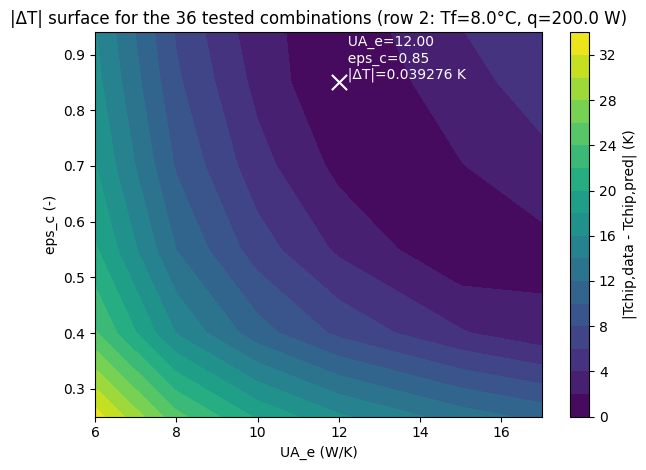

<function abs_Tchip_error at 0x7bbfb8bc2ac0>


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# The 36 tested combinations
UA_vals  = np.array([6.0, 8.0, 10.0, 12.0, 15.0, 17.0])
eps_vals = np.array([0.25, 0.40, 0.55, 0.70, 0.85, 0.94])

ERR36 = np.empty((len(eps_vals), len(UA_vals)), dtype=float)

for i, eps_c in enumerate(eps_vals):
    for j, UA_e in enumerate(UA_vals):
        ERR36[i, j] = abs_Tchip_error(UA_e, eps_c)

# Minimum among the 36 (ignore NaNs)
min_idx = np.nanargmin(ERR36)
i_min, j_min = np.unravel_index(min_idx, ERR36.shape)

UA_best_36  = UA_vals[j_min]
eps_best_36 = eps_vals[i_min]
err_best_36 = ERR36[i_min, j_min]

print("\n=== Minimum among the 36 tested points ===")
print(f"UA_e*      = {UA_best_36:.6f} W/K")
print(f"eps_c*     = {eps_best_36:.6f} (-)")
print(f"min |ΔT|   = {err_best_36:.12f} K")

# Create mesh for plotting
UA_M, EPS_M = np.meshgrid(UA_vals, eps_vals)

plt.figure()
cs = plt.contourf(UA_M, EPS_M, ERR36, levels=20)
plt.colorbar(cs, label="|Tchip,data - Tchip,pred| (K)")

plt.scatter(UA_best_36, eps_best_36, marker="x", s=120, color="white")

plt.text(
    UA_best_36, eps_best_36,
    f"  min\n  UA_e={UA_best_36:.2f}\n  eps_c={eps_best_36:.2f}\n  |ΔT|={err_best_36:.6f} K",
    verticalalignment="bottom",
    color="white"
)

plt.xlabel("UA_e (W/K)")
plt.ylabel("eps_c (-)")
plt.title(f"|ΔT| surface for the 36 tested combinations (row {row_i}: Tf={Tf_C:.1f}°C, q={q_dot:.1f} W)")
plt.tight_layout()
plt.show()

print(abs_Tchip_error)

Row 2: Tf=8.0 °C, q=200.0 W, Tchip,data=32.4 °C

=== Coarse minimum ===
UA_e*       = 12.900000 W/K
eps_c*      = 0.725000 (-)
min |ΔT|    = 0.000494815491095 K

=== Refined minimum ===
UA_e_best   = 12.6200000000 W/K
eps_c_best  = 0.7590000000 (-)
min |ΔT|    = 8.09828831052e-05 K


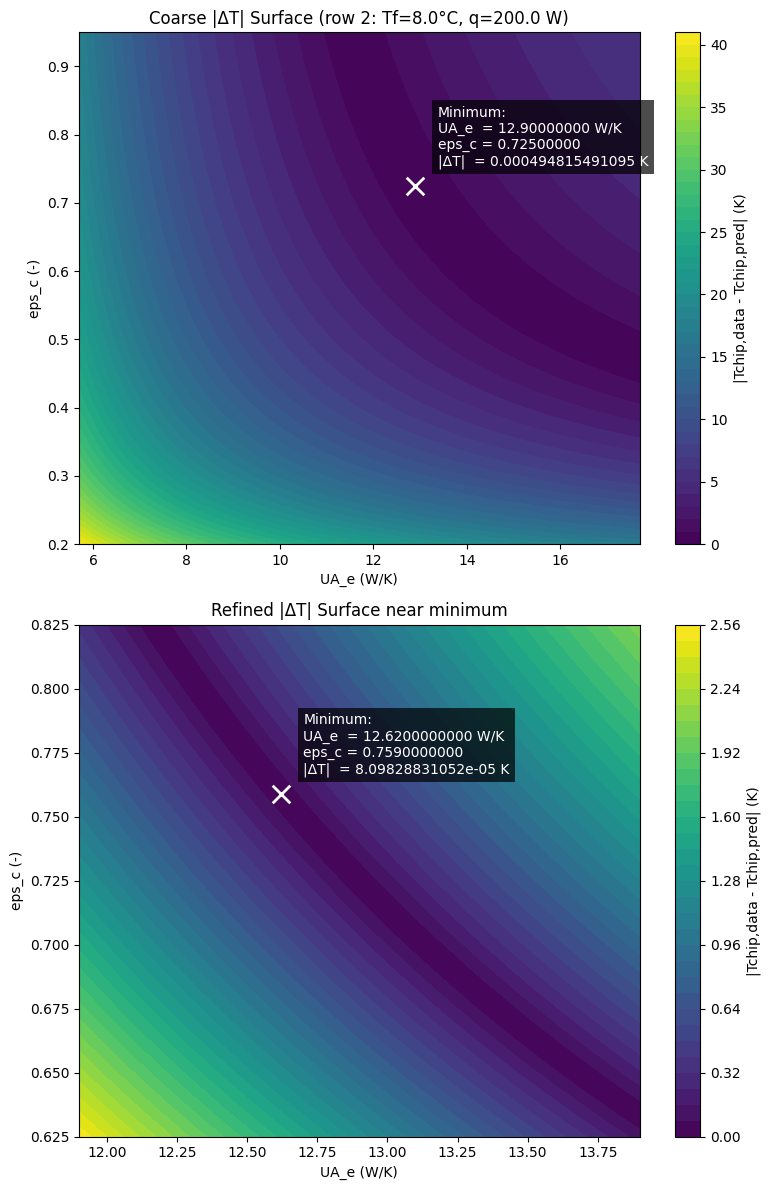

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Choose the experimental row
# -----------------------------
row_i = 2
Tf_C, q_dot, Tchip_data_C = data_rows[row_i]
Tchip_data_K = Tchip_data_C + 273.0

print(f"Row {row_i}: Tf={Tf_C:.1f} °C, q={q_dot:.1f} W, Tchip,data={Tchip_data_C:.1f} °C")

# ------------------------------------------------------------
# Model error function: returns |Tchip,data - Tchip,pred| (K)
# Returns NaN for unphysical (capillary limit exceeded) points
# ------------------------------------------------------------
def abs_Tchip_error(UA_e, eps_c):
    Tf_cond_in = Tf_C + 273.0
    T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)
    P2 = math.exp(C0 + C1 / T2)

    WA = (P2 - PB) * (P2 - PC) * (P2 - PD) / ((PA - PB) * (PA - PC) * (PA - PD))
    WB = (P2 - PA) * (P2 - PC) * (P2 - PD) / ((PB - PA) * (PB - PC) * (PB - PD))
    WC = (P2 - PA) * (P2 - PB) * (P2 - PD) / ((PC - PA) * (PC - PB) * (PC - PD))
    WD = (P2 - PA) * (P2 - PB) * (P2 - PC) / ((PD - PA) * (PD - PB) * (PD - PC))

    rhov = WA * rhov15 + WB * rhov30 + WC * rhov45 + WD * rhov60
    rhol = WA * rhol15 + WB * rhol30 + WC * rhol45 + WD * rhol60
    muv  = WA * muv15  + WB * muv30  + WC * muv45  + WD * muv60
    mul  = WA * mul15  + WB * mul30  + WC * mul45  + WD * mul60
    sig  = WA * sig15  + WB * sig30  + WC * sig45  + WD * sig60
    hlv  = WA * hlv15  + WB * hlv30  + WC * hlv45  + WD * hlv60

    m_dot_v = q_dot / hlv
    Vv = m_dot_v / (rhov * Av)
    Re_v = (rhov * Vv * Dv) / muv
    fv = 16.0 / Re_v
    deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)
    P1 = P2 + deltaP_v

    deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)
    P1_minus_P4 = deltaP_v + deltaP_l

    re = (2.0 * sig) / P1_minus_P4
    if re <= re_min:
        return np.nan

    Nre = (2.0 * sig) / (re * rhol * R * Tc)
    T1 = (C1_vii - Nre * Tc) / math.log(P1 / P0)

    Tchip_pred = T1 + q_dot / UA_e
    return abs(Tchip_data_K - Tchip_pred)


# ============================================================
# (A) Coarse grid over full required ranges
# ============================================================
UA_min, UA_max = 5.7, 17.7
eps_min, eps_max = 0.2, 0.95

n_UA_coarse  = 81
n_eps_coarse = 81

UA_grid  = np.linspace(UA_min, UA_max, n_UA_coarse)
eps_grid = np.linspace(eps_min, eps_max, n_eps_coarse)

ERR = np.empty((n_eps_coarse, n_UA_coarse), dtype=float)

for i, eps_c in enumerate(eps_grid):
    for j, UA_e in enumerate(UA_grid):
        ERR[i, j] = abs_Tchip_error(UA_e, eps_c)

i_min, j_min = np.unravel_index(np.nanargmin(ERR), ERR.shape)

UA_best_coarse  = UA_grid[j_min]
eps_best_coarse = eps_grid[i_min]
err_best_coarse = ERR[i_min, j_min]

print("\n=== Coarse minimum ===")
print(f"UA_e*       = {UA_best_coarse:.6f} W/K")
print(f"eps_c*      = {eps_best_coarse:.6f} (-)")
print(f"min |ΔT|    = {err_best_coarse:.12g} K")


# ============================================================
# (B) Refined grid around the coarse minimum
# ============================================================
UA_halfwidth  = 1.0    # W/K
eps_halfwidth = 0.10   # (-)

UA_ref_min  = max(UA_min,  UA_best_coarse  - UA_halfwidth)
UA_ref_max  = min(UA_max,  UA_best_coarse  + UA_halfwidth)
eps_ref_min = max(eps_min, eps_best_coarse - eps_halfwidth)
eps_ref_max = min(eps_max, eps_best_coarse + eps_halfwidth)

n_UA_fine  = 201
n_eps_fine = 201

UA_ref  = np.linspace(UA_ref_min, UA_ref_max, n_UA_fine)
eps_ref = np.linspace(eps_ref_min, eps_ref_max, n_eps_fine)

ERR_ref = np.empty((n_eps_fine, n_UA_fine), dtype=float)

for i, eps_c in enumerate(eps_ref):
    for j, UA_e in enumerate(UA_ref):
        ERR_ref[i, j] = abs_Tchip_error(UA_e, eps_c)

i2, j2 = np.unravel_index(np.nanargmin(ERR_ref), ERR_ref.shape)

UA_best  = UA_ref[j2]
eps_best = eps_ref[i2]
err_best = ERR_ref[i2, j2]

print("\n=== Refined minimum ===")
print(f"UA_e_best   = {UA_best:.10f} W/K")
print(f"eps_c_best  = {eps_best:.10f} (-)")
print(f"min |ΔT|    = {err_best:.12g} K")


# ============================================================
# (C) Plot both surfaces
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

# --- 1) COARSE SURFACE ---
UA_M, EPS_M = np.meshgrid(UA_grid, eps_grid)

cs1 = axes[0].contourf(UA_M, EPS_M, ERR, levels=40)
fig.colorbar(cs1, ax=axes[0], label="|Tchip,data - Tchip,pred| (K)")

axes[0].scatter(
    UA_best_coarse, eps_best_coarse,
    marker="x", s=160, linewidths=2, color="white"
)

dUA1  = 0.04 * (UA_max - UA_min)
deps1 = 0.04 * (eps_max - eps_min)

axes[0].text(
    UA_best_coarse + dUA1,
    eps_best_coarse + deps1,
    "Minimum:\n"
    f"UA_e  = {UA_best_coarse:.8f} W/K\n"
    f"eps_c = {eps_best_coarse:.8f}\n"
    f"|ΔT|  = {err_best_coarse:.12g} K",
    color="white",
    fontsize=10,
    bbox=dict(facecolor="black", alpha=0.7, edgecolor="none")
)

axes[0].set_xlabel("UA_e (W/K)")
axes[0].set_ylabel("eps_c (-)")
axes[0].set_title(f"Coarse |ΔT| Surface (row {row_i}: Tf={Tf_C:.1f}°C, q={q_dot:.1f} W)")

# --- 2) REFINED SURFACE ---
UA_M2, EPS_M2 = np.meshgrid(UA_ref, eps_ref)

cs2 = axes[1].contourf(UA_M2, EPS_M2, ERR_ref, levels=40)
fig.colorbar(cs2, ax=axes[1], label="|Tchip,data - Tchip,pred| (K)")

axes[1].scatter(
    UA_best, eps_best,
    marker="x", s=160, linewidths=2, color="white"
)

dUA2  = 0.04 * (UA_ref.max() - UA_ref.min())
deps2 = 0.04 * (eps_ref.max() - eps_ref.min())

axes[1].text(
    UA_best + dUA2,
    eps_best + deps2,
    "Minimum:\n"
    f"UA_e  = {UA_best:.10f} W/K\n"
    f"eps_c = {eps_best:.10f}\n"
    f"|ΔT|  = {err_best:.12g} K",
    color="white",
    fontsize=10,
    bbox=dict(facecolor="black", alpha=0.7, edgecolor="none")
)

axes[1].set_xlabel("UA_e (W/K)")
axes[1].set_ylabel("eps_c (-)")
axes[1].set_title("Refined |ΔT| Surface near minimum")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Task 4 (a and b)
# ============================================================
import math
import numpy as np

# ============================================================
# (i) Heat pipe design + evaporator structure parameters
# ============================================================
Dp = 0.015      # m
Levap = 0.025   # m
Ladiab = 0.30   # m
Lcond = 0.025   # m

Leff = Ladiab + 0.5 * Levap + 0.5 * Lcond  # m

tw = 0.0025     # m (wick thickness; multiple layers - mesh)
UA_e = 10.8     # W/K evaporator conductance

Aw = (math.pi / 4.0) * (Dp**2 - (Dp - 2.0 * tw)**2)  # wick cross-sectional area, m^2
Dv = Dp - 2.0 * tw                                   # vapor core diameter, m
Av = (math.pi / 4.0) * (Dv**2)                        # vapor core area, m^2

rp_min = 0.000045   # m minimum pore radius
kappa = 3e-10    # m^2 permeability
theta_deg = 10.0    # degrees
theta_rad = math.radians(theta_deg)
re_min = rp_min / math.cos(theta_rad)  # m

# ============================================================
# (ii) Condenser design + operating parameters
# ============================================================
Tf_cond_in = 15.5 + 273.0  # K
q_dot = 68.0              # W
m_dot_c = 0.0080           # kg/s
eps_c = 0.6                # condenser heat exchanger effectiveness
cp_f = 4180.0              # J/(kg*K)

# ============================================================
# (iii) Determine T2, then compute P2 = Psat(T2)
# ============================================================
T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)  # K

# Given correlation: Psat(T) = exp(C0 - C1/T)
##use the saturation pressure values for methanol at 10 adn 50C to get c0 and c1
C0 = 22.9826
C1 = 3899.6080
P2 = math.exp(C0 - C1 / T2)  # units per correlation (treat as Pa in this assignment context)

# ============================================================
# (iv) Lagrange interpolation in pressure-space using anchors
#     Anchors are Psat at 10/30/50/70 C (given) and saturated
#     properties at those temperatures (from your table page).
# ============================================================

#for metahnol, set ideal gas constant R and critical temp
#from from Engineering Toolbox (https://www.engineeringtoolbox.com/methanol-methyl-alcohol-properties-CH3OH-d_2031.html)
R = 259.5 #J/kgK
Tc = 513.4 #K

# Psat anchor points (Pa) at 10/30/50/70 °C (from table) converted from bar to Pa manually
PA = 10e3
PB = 25e3
PC = 55e3
PD = 131e3

# ---- Saturated properties at 10/30/50/70 °C from the table ----
# Densities (kg/m^3): from table
# Liquid density from table
rhol10, rhol30, rhol50, rhol70 = 801, 782, 764, 746

# Vapor densities (kg/m^3)
rhov10 = 0.12
rhov30 = 0.31
rhov50 = 0.77
rhov70 = 1.47

# Viscosities from table to convert to Pa·s (multiply by 1e-3 for liquid and by 1e-5 for vapor)
mul10, mul30, mul50, mul70 = 0.701e-3, 0.521e-3, 0.399e-3, 0.314e-3
muv10, muv30, muv50, muv70 = 0.91e-5,   0.98e-5,  1.04e-5,  1.11e-5

# Surface tension from table convert to N/m (multiply by e-2)
sig10, sig30, sig50, sig70 = 2.36e-2, 2.18e-2, 2.01e-2, 1.85e-2

# Latent heat convert to J/kg (multiply by e3)
hlv10 = 1175 * 1e3
hlv30 = 1155 * 1e3
hlv50 = 1125 * 1e3
hlv70 = 1085 * 1e3

# ---- Lagrange weights (exactly as professor wrote) ----
WA = (P2 - PB) * (P2 - PC) * (P2 - PD) / ((PA - PB) * (PA - PC) * (PA - PD))
WB = (P2 - PA) * (P2 - PC) * (P2 - PD) / ((PB - PA) * (PB - PC) * (PB - PD))
WC = (P2 - PA) * (P2 - PB) * (P2 - PD) / ((PC - PA) * (PC - PB) * (PC - PD))
WD = (P2 - PA) * (P2 - PB) * (P2 - PC) / ((PD - PA) * (PD - PB) * (PD - PC))

# ---- Interpolated saturated properties at P2 ----
rhov = WA * rhov10 + WB * rhov30 + WC * rhov50 + WD * rhov70
rhol = WA * rhol10 + WB * rhol30 + WC * rhol50 + WD * rhol70
muv  = WA * muv10  + WB * muv30  + WC * muv50  + WD * muv70
mul  = WA * mul10  + WB * mul30  + WC * mul50  + WD * mul70
sig  = WA * sig10  + WB * sig30  + WC * sig50  + WD * sig70
hlv  = WA * hlv10  + WB * hlv30  + WC * hlv50  + WD * hlv70

# ============================================================
# Print results
# ============================================================
print("=== (i) Geometry / Wick ===")
print(f"Leff   = {Leff:.6f} m")
print(f"Aw     = {Aw:.8e} m^2")
print(f"Dv     = {Dv:.6f} m")
print(f"Av     = {Av:.8e} m^2")
print(f"re_min = {re_min:.8e} m")

print("\n=== (iii) Condenser end state ===")
print(f"T2 = {T2:.6f} K")
print(f"P2 = {P2:.6e} (per Psat correlation)")

print("\n=== (iv) Lagrange weights ===")
print(f"WA, WB, WC, WD = {WA:.6g}, {WB:.6g}, {WC:.6g}, {WD:.6g}")
print(f"Sum weights     = {(WA+WB+WC+WD):.6g}")

print("\n=== (iv) Saturated properties at P2 (interpolated) ===")
print(f"rhov = {rhov:.6g} kg/m^3")
print(f"rhol = {rhol:.6g} kg/m^3")
print(f"muv  = {muv:.6g} Pa·s")
print(f"mul  = {mul:.6g} Pa·s")
print(f"sig  = {sig:.6g} N/m")
print(f"hlv  = {hlv:.6g} J/kg")

# ============================================================
# (v) Vapor-flow pressure drop and P1
# ============================================================

# --- sanity checks (avoid silent crashes / nonsense) ---
if hlv <= 0:
    raise ValueError(f"hlv must be > 0 (J/kg). Got {hlv}.")
if rhov <= 0:
    raise ValueError(f"rhov must be > 0 (kg/m^3). Got {rhov}.")
if Av <= 0 or Dv <= 0:
    raise ValueError(f"Av and Dv must be > 0. Got Av={Av}, Dv={Dv}.")
if muv <= 0:
    raise ValueError(f"muv must be > 0 (Pa·s). Got {muv}.")
if Leff <= 0:
    raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

# Mass flow rate of vapor (kg/s)
m_dot_v = q_dot / hlv

# Vapor average velocity (m/s)
Vv = m_dot_v / (rhov * Av)

# Vapor Reynolds number (-)
Re_v = (rhov * Vv * Dv) / muv

# Fanning friction factor (laminar) (-)
fv = 16.0 / Re_v

# Vapor pressure rise from condenser end (P2) to evaporator end (P1) due to flow (Pa)
deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)

# Pressure at evaporator end (Pa)
P1 = P2 + deltaP_v

print("\n=== (v) Vapor flow / pressure drop ===")
print(f"m_dot_v   = {m_dot_v:.6g} kg/s")
print(f"Vv        = {Vv:.6g} m/s")
print(f"Re_v      = {Re_v:.6g} (-)")
print(f"f_v       = {fv:.6g} (-)")
print(f"deltaP_v  = {deltaP_v:.6g} Pa")
print(f"P1        = {P1:.6g} Pa")
#del_p = P1- P2
#print(f"P1        = {del_p:.6g} Pa")

# ============================================================
# (vi) Liquid flow pressure drop in porous wick (Darcy) and
#      pressure difference across curved interface in evaporator
# ============================================================

# --- sanity checks ---
if mul <= 0:
    raise ValueError(f"mul must be > 0 (Pa·s). Got {mul}.")
if kappa <= 0:
    raise ValueError(f"kappa must be > 0 (m^2). Got {kappa}.")
if rhol <= 0:
    raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
if Aw <= 0:
    raise ValueError(f"Aw must be > 0 (m^2). Got {Aw}.")
if m_dot_v <= 0:
    raise ValueError(f"m_dot_v must be > 0 (kg/s). Got {m_dot_v}.")
if Leff <= 0:
    raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

# Liquid flow pressure drop through wick (Pa)
# (m_dot is the same mass flow rate circulating: m_dot_v = q_dot/hlv)
deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)   # P3 - P4

# Total pressure difference from 1 to 4 (Pa)
# P2 = P3, so P1 - P4 = (P1 - P2) + (P3 - P4)
# From step (v): deltaP_v = P1 - P2
P1_minus_P4 = deltaP_v + deltaP_l

print("\n=== (vi) Wick (liquid) pressure drop + interface pressure difference ===")
print(f"deltaP_l (P3-P4) = {deltaP_l:.6g} Pa")
print(f"P1 - P4          = {P1_minus_P4:.6g} Pa")

# ============================================================
# (vii) Curved-interface equilibrium + saturation curve relation:

# Notes:
# - Uses sigma (N/m), re (m), rho_l (kg/m^3), R (J/kgK), Tc (K)
# - Requires P1 already computed in step (v), and deltaP_v/deltaP_l from (v)-(vi)
# ============================================================

# --- sanity checks ---
if sig <= 0:
    raise ValueError(f"sig must be > 0 (N/m). Got {sig}.")
if P1_minus_P4 <= 0:
    raise ValueError(f"P1_minus_P4 must be > 0 (Pa). Got {P1_minus_P4}.")
if rhol <= 0:
    raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
if R <= 0 or Tc <= 0:
    raise ValueError(f"R and Tc must be > 0. Got R={R}, Tc={Tc}.")

# 1) Interface radius from pressure difference (m)
re = (2.0 * sig) / P1_minus_P4

# Enforce constraint re > re_min
if re <= re_min:
    raise ValueError(
        f"Computed re={re:.3e} m is <= re_min={re_min:.3e} m. "
        "This violates the interface-radius constraint (capillary limit exceeded)."
    )

# 2) Compute T1 using provided rearranged relation
# Constants from handout (note C1 slightly different from earlier step)
C0_vii = 25.73
C1_vii = -5266.3  # K

P0 = math.exp(C0_vii)

# Dimensionless Nre (uses Tc as in handout)
Nre = (2.0 * sig) / (re * rhol * R * Tc)

# Compute T1
ln_P1_over_P0 = math.log(P1 / P0)
if ln_P1_over_P0 == 0:
    raise ValueError("ln(P1/P0) is zero; cannot compute T1.")

T1 = (C1_vii - Nre * Tc) / ln_P1_over_P0  # K

print("\n=== (vii) Curved-interface equilibrium ===")
print(f"re              = {re:.6e} m")
print(f"re_min          = {re_min:.6e} m")
print(f"Nre             = {Nre:.6e} (-)")
print(f"P0              = {P0:.6e} (same pressure units as P1)")
print(f"ln(P1/P0)       = {ln_P1_over_P0:.6e}")
print(f"T1              = {T1:.6f} K")

# ============================================================
# (viii) Chip temperature
# ============================================================

# --- sanity checks ---
if UA_e <= 0:
    raise ValueError(f"UA_e must be > 0 (W/K). Got {UA_e}.")
if q_dot < 0:
    raise ValueError(f"q_dot must be >= 0 (W). Got {q_dot}.")
if not math.isfinite(T1):
    raise ValueError(f"T1 must be finite. Got {T1}.")
if not math.isfinite(re):
    raise ValueError(f"re must be finite. Got {re}.")

T_chip = T1 + q_dot / UA_e  # K

# Physical realism checks for interface radius
capillary_ok = (re > re_min) and math.isfinite(re)

print("\n=== (viii) Chip temperature + realism check ===")
print(f"T_chip         = {T_chip:.6f} K")
print(f"T_chip (°C)    = {T_chip - 273.15:.3f} °C")
print(f"re             = {re:.6e} m")
print(f"re_min         = {re_min:.6e} m")
print(f"capillary_ok   = {capillary_ok}")

if not capillary_ok:
    raise ValueError(
        "Physically unrealistic operating point: re must be > re_min and finite. "
        f"Got re={re:.3e}, re_min={re_min:.3e}."
    )


=== (i) Geometry / Wick ===
Leff   = 0.325000 m
Aw     = 9.81747704e-05 m^2
Dv     = 0.010000 m
Av     = 7.85398163e-05 m^2
re_min = 4.56941975e-05 m

=== (iii) Condenser end state ===
T2 = 291.889155 K
P2 = 1.510387e+04 (per Psat correlation)

=== (iv) Lagrange weights ===
WA, WB, WC, WD = 0.560242, 0.494745, -0.0570541, 0.00206724
Sum weights     = 1

=== (iv) Saturated properties at P2 (interpolated) ===
rhov = 0.179707 kg/m^3
rhol = 793.597 kg/m^3
muv  = 9.37629e-06 Pa·s
mul  = 0.000628376 Pa·s
sig  = 0.0228986 N/m
hlv  = 1.16777e+06 J/kg

=== (v) Vapor flow / pressure drop ===
m_dot_v   = 5.82306e-05 kg/s
Vv        = 4.12568 m/s
Re_v      = 790.734 (-)
f_v       = 0.0202344 (-)
deltaP_v  = 4.02309 Pa
P1        = 15107.9 Pa

=== (vi) Wick (liquid) pressure drop + interface pressure difference ===
deltaP_l (P3-P4) = 508.783 Pa
P1 - P4          = 512.806 Pa

=== (vii) Curved-interface equilibrium ===
re              = 8.930703e-05 m
re_min          = 4.569420e-05 m
Nre             = 

In [ ]:
#rhs = (delta_PV + delta_PL)
#lhs = P1 - P4
# rhs = lhs = 0 for steady state capilary balance conditions
rhs =  4.620 + 594.132
lhs = 598.746 #2*()/(7.631082e-05)
val = rhs - lhs
print (val) #80 W

0.005999999999971806


In [ ]:
rhs = 3.61058 + 451.126
lhs = 454.737
val = rhs - lhs
print (val)  #60 W

-0.0004200000000196269


In [ ]:
#70 W
rhs = 4.12386 + 523.103
lhs = 527.227
val = rhs - lhs
print (val)

-0.0001399999999875945


In [ ]:
#68
rhs =4.02309 + 508.783
lhs = 512.806
val = rhs - lhs
print (val)


9.000000000014552e-05


=== (i) Geometry / Wick ===
Leff   = 0.325000 m
Aw     = 9.81747704e-05 m^2
Dv     = 0.010000 m
Av     = 7.85398163e-05 m^2
re_min = 4.56941975e-05 m

=== (iii) Condenser end state ===
T2 = 289.496810 K
P2 = 1.352511e+04 (per Psat correlation)

=== (iv) Lagrange weights ===
WA, WB, WC, WD = 0.684526, 0.360068, -0.0463147, 0.00172108
Sum weights     = 1

=== (iv) Saturated properties at P2 (interpolated) ===
rhov = 0.160632 kg/m^3
rhol = 795.778 kg/m^3
muv  = 9.29528e-06 Pa·s
mul  = 0.000649509 Pa·s
sig  = 0.0231052 N/m
hlv  = 1.16996e+06 J/kg

=== (v) Vapor flow / pressure drop ===
m_dot_v   = 1.70946e-05 kg/s
Vv        = 1.355 m/s
Re_v      = 234.157 (-)
f_v       = 0.0683303 (-)
deltaP_v  = 1.30989 Pa
P1        = 13526.4 Pa

=== (vi) Wick (liquid) pressure drop + interface pressure difference ===
deltaP_l (P3-P4) = 153.962 Pa
P1 - P4          = 155.272 Pa

=== (vii) Curved-interface equilibrium ===
re              = 2.976089e-04 m
re_min          = 4.569420e-05 m
Nre             = 1.

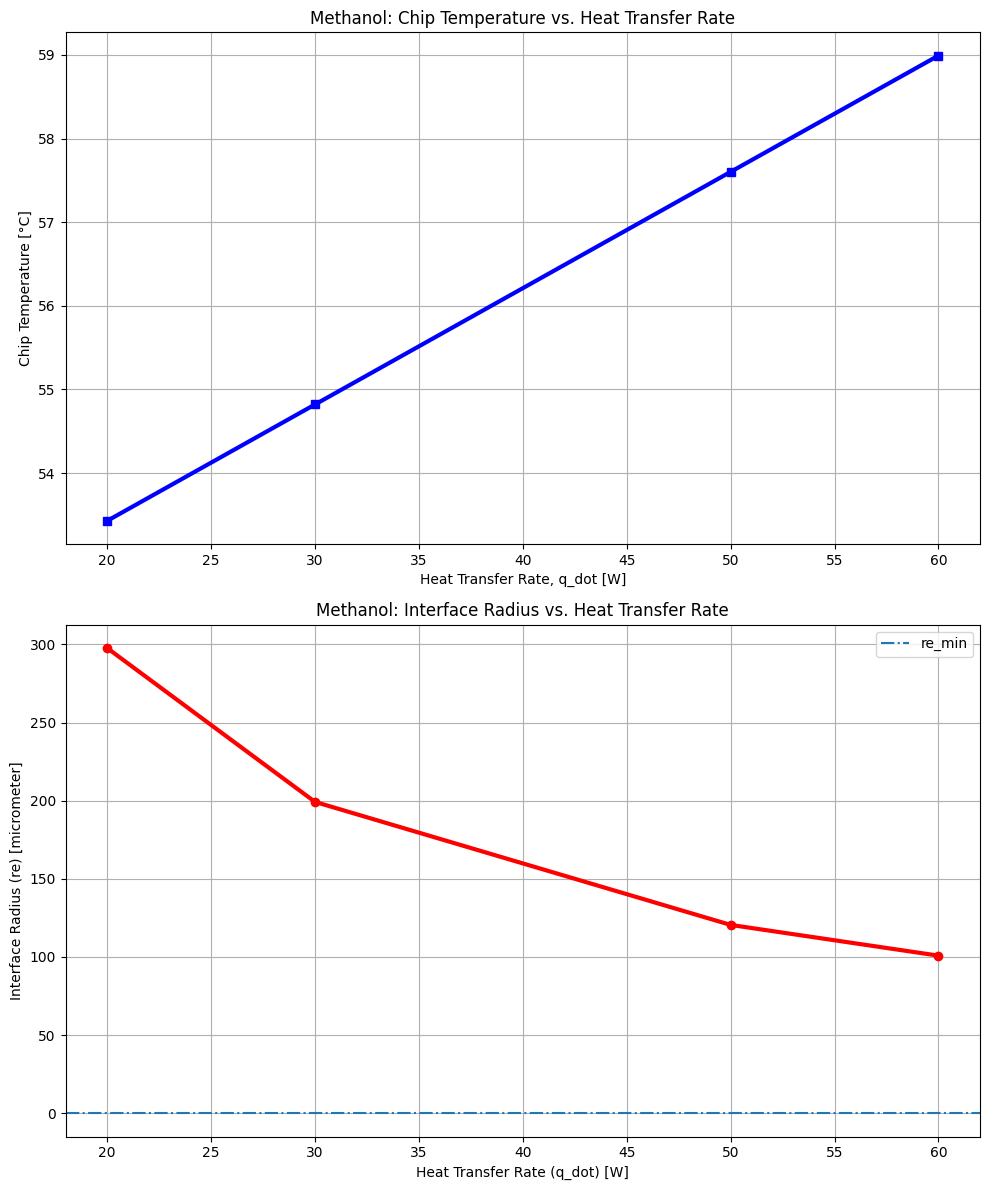

In [ ]:
# ============================================================
# Task 4 (c)
# ============================================================
import math
import numpy as np
import matplotlib.pyplot as plt
# ============================================================
# (i) Heat pipe design + evaporator structure parameters
# ============================================================
Dp = 0.015      # m
Levap = 0.025   # m
Ladiab = 0.30   # m
Lcond = 0.025   # m

Leff = Ladiab + 0.5 * Levap + 0.5 * Lcond  # m

tw = 0.0025     # m (wick thickness; multiple layers - mesh)
UA_e = 10.8     # W/K evaporator conductance

Aw = (math.pi / 4.0) * (Dp**2 - (Dp - 2.0 * tw)**2)  # wick cross-sectional area, m^2
Dv = Dp - 2.0 * tw                                   # vapor core diameter, m
Av = (math.pi / 4.0) * (Dv**2)                        # vapor core area, m^2

rp_min = 0.000045   # m minimum pore radius
kappa = 3e-10    # m^2 permeability
theta_deg = 10.0    # degrees
theta_rad = math.radians(theta_deg)
re_min = rp_min / math.cos(theta_rad)  # m

# ============================================================
# (ii) Condenser design + operating parameters
# ============================================================
Tf_cond_in = 15.5 + 273.0  # K
q_dot_array = [20.0, 30.0, 50.0, 60.0]              # W
m_dot_c = 0.0080           # kg/s
eps_c = 0.6                # condenser heat exchanger effectiveness
cp_f = 4180.0              # J/(kg*K)

#initialize arrays to store the re and T_chip values in
re_array = []
T_chip_array = []

for q_dot in q_dot_array:
  # ============================================================
  # (iii) Determine T2, then compute P2 = Psat(T2)
  # ============================================================
  T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)  # K

  # Given correlation: Psat(T) = exp(C0 - C1/T)
  ##use the saturation pressure values for methanol at 10 adn 50C to get c0 and c1
  C0 = 22.9826
  C1 = 3899.6080
  P2 = math.exp(C0 - C1 / T2)  # units per correlation (treat as Pa in this assignment context)

  # ============================================================
  # (iv) Lagrange interpolation in pressure-space using anchors
  #     Anchors are Psat at 10/30/50/70 C (given) and saturated
  #     properties at those temperatures (from your table page).
  # ============================================================

  #for metahnol, set ideal gas constant R and critical temp
  #from from Engineering Toolbox (https://www.engineeringtoolbox.com/methanol-methyl-alcohol-properties-CH3OH-d_2031.html)
  R = 259.5 #J/kgK
  Tc = 513.4 #K

  # Psat anchor points (Pa) at 10/30/50/70 °C (from table) converted from bar to Pa manually
  PA = 10e3
  PB = 25e3
  PC = 55e3
  PD = 131e3

  # ---- Saturated properties at 10/30/50/70 °C from the table ----
  # Densities (kg/m^3): from table
  # Liquid density from table
  rhol10, rhol30, rhol50, rhol70 = 801, 782, 764, 746

  # Vapor densities (kg/m^3)
  rhov10 = 0.12
  rhov30 = 0.31
  rhov50 = 0.77
  rhov70 = 1.47

  # Viscosities from table to convert to Pa·s (multiply by 1e-3 for liquid and by 1e-5 for vapor)
  mul10, mul30, mul50, mul70 = 0.701e-3, 0.521e-3, 0.399e-3, 0.314e-3
  muv10, muv30, muv50, muv70 = 0.91e-5,   0.98e-5,  1.04e-5,  1.11e-5

  # Surface tension from table convert to N/m (multiply by e-2)
  sig10, sig30, sig50, sig70 = 2.36e-2, 2.18e-2, 2.01e-2, 1.85e-2

  # Latent heat convert to J/kg (multiply by e3)
  hlv10 = 1175 * 1e3
  hlv30 = 1155 * 1e3
  hlv50 = 1125 * 1e3
  hlv70 = 1085 * 1e3

  # ---- Lagrange weights (exactly as professor wrote) ----
  WA = (P2 - PB) * (P2 - PC) * (P2 - PD) / ((PA - PB) * (PA - PC) * (PA - PD))
  WB = (P2 - PA) * (P2 - PC) * (P2 - PD) / ((PB - PA) * (PB - PC) * (PB - PD))
  WC = (P2 - PA) * (P2 - PB) * (P2 - PD) / ((PC - PA) * (PC - PB) * (PC - PD))
  WD = (P2 - PA) * (P2 - PB) * (P2 - PC) / ((PD - PA) * (PD - PB) * (PD - PC))

  # ---- Interpolated saturated properties at P2 ----
  rhov = WA * rhov10 + WB * rhov30 + WC * rhov50 + WD * rhov70
  rhol = WA * rhol10 + WB * rhol30 + WC * rhol50 + WD * rhol70
  muv  = WA * muv10  + WB * muv30  + WC * muv50  + WD * muv70
  mul  = WA * mul10  + WB * mul30  + WC * mul50  + WD * mul70
  sig  = WA * sig10  + WB * sig30  + WC * sig50  + WD * sig70
  hlv  = WA * hlv10  + WB * hlv30  + WC * hlv50  + WD * hlv70

  # ============================================================
  # Print results
  # ============================================================
  print("=== (i) Geometry / Wick ===")
  print(f"Leff   = {Leff:.6f} m")
  print(f"Aw     = {Aw:.8e} m^2")
  print(f"Dv     = {Dv:.6f} m")
  print(f"Av     = {Av:.8e} m^2")
  print(f"re_min = {re_min:.8e} m")

  print("\n=== (iii) Condenser end state ===")
  print(f"T2 = {T2:.6f} K")
  print(f"P2 = {P2:.6e} (per Psat correlation)")

  print("\n=== (iv) Lagrange weights ===")
  print(f"WA, WB, WC, WD = {WA:.6g}, {WB:.6g}, {WC:.6g}, {WD:.6g}")
  print(f"Sum weights     = {(WA+WB+WC+WD):.6g}")

  print("\n=== (iv) Saturated properties at P2 (interpolated) ===")
  print(f"rhov = {rhov:.6g} kg/m^3")
  print(f"rhol = {rhol:.6g} kg/m^3")
  print(f"muv  = {muv:.6g} Pa·s")
  print(f"mul  = {mul:.6g} Pa·s")
  print(f"sig  = {sig:.6g} N/m")
  print(f"hlv  = {hlv:.6g} J/kg")

  # ============================================================
  # (v) Vapor-flow pressure drop and P1
  # ============================================================

  # --- sanity checks (avoid silent crashes / nonsense) ---
  if hlv <= 0:
      raise ValueError(f"hlv must be > 0 (J/kg). Got {hlv}.")
  if rhov <= 0:
      raise ValueError(f"rhov must be > 0 (kg/m^3). Got {rhov}.")
  if Av <= 0 or Dv <= 0:
      raise ValueError(f"Av and Dv must be > 0. Got Av={Av}, Dv={Dv}.")
  if muv <= 0:
      raise ValueError(f"muv must be > 0 (Pa·s). Got {muv}.")
  if Leff <= 0:
      raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

  # Mass flow rate of vapor (kg/s)
  m_dot_v = q_dot / hlv

  # Vapor average velocity (m/s)
  Vv = m_dot_v / (rhov * Av)

  # Vapor Reynolds number (-)
  Re_v = (rhov * Vv * Dv) / muv

  # Fanning friction factor (laminar) (-)
  fv = 16.0 / Re_v

  # Vapor pressure rise from condenser end (P2) to evaporator end (P1) due to flow (Pa)
  deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)

  # Pressure at evaporator end (Pa)
  P1 = P2 + deltaP_v

  print("\n=== (v) Vapor flow / pressure drop ===")
  print(f"m_dot_v   = {m_dot_v:.6g} kg/s")
  print(f"Vv        = {Vv:.6g} m/s")
  print(f"Re_v      = {Re_v:.6g} (-)")
  print(f"f_v       = {fv:.6g} (-)")
  print(f"deltaP_v  = {deltaP_v:.6g} Pa")
  print(f"P1        = {P1:.6g} Pa")
  #del_p = P1- P2
  #print(f"P1        = {del_p:.6g} Pa")

  # ============================================================
  # (vi) Liquid flow pressure drop in porous wick (Darcy) and
  #      pressure difference across curved interface in evaporator
  # ============================================================

  # --- sanity checks ---
  if mul <= 0:
      raise ValueError(f"mul must be > 0 (Pa·s). Got {mul}.")
  if kappa <= 0:
      raise ValueError(f"kappa must be > 0 (m^2). Got {kappa}.")
  if rhol <= 0:
      raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
  if Aw <= 0:
      raise ValueError(f"Aw must be > 0 (m^2). Got {Aw}.")
  if m_dot_v <= 0:
      raise ValueError(f"m_dot_v must be > 0 (kg/s). Got {m_dot_v}.")
  if Leff <= 0:
      raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

  # Liquid flow pressure drop through wick (Pa)
  # (m_dot is the same mass flow rate circulating: m_dot_v = q_dot/hlv)
  deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)   # P3 - P4

  # Total pressure difference from 1 to 4 (Pa)
  # P2 = P3, so P1 - P4 = (P1 - P2) + (P3 - P4)
  # From step (v): deltaP_v = P1 - P2
  P1_minus_P4 = deltaP_v + deltaP_l

  print("\n=== (vi) Wick (liquid) pressure drop + interface pressure difference ===")
  print(f"deltaP_l (P3-P4) = {deltaP_l:.6g} Pa")
  print(f"P1 - P4          = {P1_minus_P4:.6g} Pa")

  # ============================================================
  # (vii) Curved-interface equilibrium + saturation curve relation:

  # Notes:
  # - Uses sigma (N/m), re (m), rho_l (kg/m^3), R (J/kgK), Tc (K)
  # - Requires P1 already computed in step (v), and deltaP_v/deltaP_l from (v)-(vi)
  # ============================================================

  # --- sanity checks ---
  if sig <= 0:
      raise ValueError(f"sig must be > 0 (N/m). Got {sig}.")
  if P1_minus_P4 <= 0:
      raise ValueError(f"P1_minus_P4 must be > 0 (Pa). Got {P1_minus_P4}.")
  if rhol <= 0:
      raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
  if R <= 0 or Tc <= 0:
      raise ValueError(f"R and Tc must be > 0. Got R={R}, Tc={Tc}.")

  # 1) Interface radius from pressure difference (m)
  re = (2.0 * sig) / P1_minus_P4

  # Enforce constraint re > re_min
  if re <= re_min:
      raise ValueError(
          f"Computed re={re:.3e} m is <= re_min={re_min:.3e} m. "
          "This violates the interface-radius constraint (capillary limit exceeded)."
      )

  # 2) Compute T1 using provided rearranged relation
  # Constants from handout (note C1 slightly different from earlier step)
  C0_vii = 25.73
  C1_vii = -5266.3  # K

  P0 = math.exp(C0_vii)

  # Dimensionless Nre (uses Tc as in handout)
  Nre = (2.0 * sig) / (re * rhol * R * Tc)

  # Compute T1
  ln_P1_over_P0 = math.log(P1 / P0)
  if ln_P1_over_P0 == 0:
      raise ValueError("ln(P1/P0) is zero; cannot compute T1.")

  T1 = (C1_vii - Nre * Tc) / ln_P1_over_P0  # K

  print("\n=== (vii) Curved-interface equilibrium ===")
  print(f"re              = {re:.6e} m")
  print(f"re_min          = {re_min:.6e} m")
  print(f"Nre             = {Nre:.6e} (-)")
  print(f"P0              = {P0:.6e} (same pressure units as P1)")
  print(f"ln(P1/P0)       = {ln_P1_over_P0:.6e}")
  print(f"T1              = {T1:.6f} K")

  # ============================================================
  # (viii) Chip temperature
  # ============================================================

  # --- sanity checks ---
  if UA_e <= 0:
      raise ValueError(f"UA_e must be > 0 (W/K). Got {UA_e}.")
  if q_dot < 0:
      raise ValueError(f"q_dot must be >= 0 (W). Got {q_dot}.")
  if not math.isfinite(T1):
      raise ValueError(f"T1 must be finite. Got {T1}.")
  if not math.isfinite(re):
      raise ValueError(f"re must be finite. Got {re}.")

  T_chip = T1 + q_dot / UA_e  # K

  #append values of T_chip and re to the initialized arrays to store
  T_chip_array.append(T_chip)
  re_array.append(re)

  # Physical realism checks for interface radius
  capillary_ok = (re > re_min) and math.isfinite(re)

  print("\n=== (viii) Chip temperature + realism check ===")
  print(f"q_dot = {q_dot} W")
  print(f"T_chip         = {T_chip:.6f} K")
  print(f"T_chip (°C)    = {T_chip - 273.15:.3f} °C")
  print(f"re             = {re:.6e} m")
  print(f"re_min         = {re_min:.6e} m")
  print(f"capillary_ok   = {capillary_ok}")

  if not capillary_ok:
      raise ValueError(
          "Physically unrealistic operating point: re must be > re_min and finite. "
          f"Got re={re:.3e}, re_min={re_min:.3e}."
      )


  # ============================================================
  # Is the system stable? (Capillary Limit Check)
  # ============================================================
  #rhs = (delta_PV + delta_PL)
  #lhs = P1 - P4 = 2sigma/re_min
  # rhs = lhs = 0 for steady state capilary balance conditions
  rhs = deltaP_v + deltaP_l
  lhs = (2*sig)/(re_min)
  stability_val = rhs - lhs
  print(f" Stability value   = {stability_val}")

  if rhs <= lhs:
      print(f"The system is stable at {q_dot} W.")
  else:
      print(f"The system is NOT stable at {q_dot} W.")

#print the arrays that store the values of T_chip and re for the different q_dot iteration values
print(f"\n T_chip_array is as follows: {[f'{T- 273.15:.3f}' for T in T_chip_array]}")
print(f"\n re is as follows in micrometers: {[f'{r*1e6:.3f}' for r in re_array]}")

#make plots for the relations between T_chip and q_dot and re and q_dot

#create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

#unit conversions for plotting
T_chip_array_C = []
for t in T_chip_array:
  T_chip_array_C.append(t - 273.15)

re_array_micro = []
for r in re_array:
  re_array_micro.append(r*1e6)

print (T_chip_array_C)
print(re_array_micro)
#plot 1: T_chip vs q_dot
ax1.plot(q_dot_array, T_chip_array_C, 'b-s', linewidth=3)
ax1.set_xlabel('Heat Transfer Rate, q_dot [W]')
ax1.set_ylabel('Chip Temperature [°C]')
ax1.set_title('Methanol: Chip Temperature vs. Heat Transfer Rate')
ax1.grid(True)

#plot 2: re vs q_dot
ax2.plot(q_dot_array, re_array_micro, 'r-o', linewidth=3)
ax2.axhline(y=re_min, linestyle='-.', label='re_min') #re_min reference
ax2.set_xlabel('Heat Transfer Rate (q_dot) [W]')
ax2.set_ylabel('Interface Radius (re) [micrometer]')
ax2.set_title('Methanol: Interface Radius vs. Heat Transfer Rate')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()




In [ ]:
# ============================================================
# Task 4 (d)
# ============================================================
import math
import numpy as np
import matplotlib.pyplot as plt
# ============================================================
# (i) Heat pipe design + evaporator structure parameters
# ============================================================
Dp = 0.015      # m
Levap = 0.025   # m
Ladiab = 0.30   # m
Lcond = 0.025   # m

Leff = Ladiab + 0.5 * Levap + 0.5 * Lcond  # m

tw = 0.0025     # m (wick thickness; multiple layers - mesh)
UA_e = 10.8     # W/K evaporator conductance

Aw = (math.pi / 4.0) * (Dp**2 - (Dp - 2.0 * tw)**2)  # wick cross-sectional area, m^2
Dv = Dp - 2.0 * tw                                   # vapor core diameter, m
Av = (math.pi / 4.0) * (Dv**2)                        # vapor core area, m^2

#rp_min = 0.00004    #m , decreased from 4.5e-5 to 3.5e-5 (increases capillary pressure)
#kappa = 8e-10        #m^2, increased from 3e-10 to 8e-10 (reduces pressure drop/friction)
rp_min = 0.000045   # m minimum pore radius OLD VALUES
kappa = 3e-10    # m^2 permeability  OLD VALUES
theta_deg = 10.0    # degrees
theta_rad = math.radians(theta_deg)
re_min = rp_min / math.cos(theta_rad)  # m

# ============================================================
# (ii) Condenser design + operating parameters
# ============================================================
Tf_cond_in = 15.5 + 273.0  # K
#test q_dot with 30% increase (60W*1.3 = 78W, let us test 78W)
q_dot_array = [20.0, 30.0, 50.0, 60.0, 78.0]          # W
m_dot_c = 0.0080           # kg/s
eps_c = 0.6                # condenser heat exchanger effectiveness
cp_f = 4180.0              # J/(kg*K)

#initialize arrays to store the re and T_chip values in
re_array = []
T_chip_array = []

for q_dot in q_dot_array:
  # ============================================================
  # (iii) Determine T2, then compute P2 = Psat(T2)
  # ============================================================
  T2 = Tf_cond_in + q_dot / (m_dot_c * cp_f * eps_c)  # K

  # Given correlation: Psat(T) = exp(C0 - C1/T)
  ##use the saturation pressure values for methanol at 10 adn 50C to get c0 and c1
  C0 = 22.9826
  C1 = 3899.6080
  P2 = math.exp(C0 - C1 / T2)  # units per correlation (treat as Pa in this assignment context)

  # ============================================================
  # (iv) Lagrange interpolation in pressure-space using anchors
  #     Anchors are Psat at 10/30/50/70 C (given) and saturated
  #     properties at those temperatures (from your table page).
  # ============================================================

  #for metahnol, set ideal gas constant R and critical temp
  #from from Engineering Toolbox (https://www.engineeringtoolbox.com/methanol-methyl-alcohol-properties-CH3OH-d_2031.html)
  R = 259.5 #J/kgK
  Tc = 513.4 #K

  # Psat anchor points (Pa) at 10/30/50/70 °C (from table) converted from bar to Pa manually
  PA = 10e3
  PB = 25e3
  PC = 55e3
  PD = 131e3

  # ---- Saturated properties at 10/30/50/70 °C from the table ----
  # Densities (kg/m^3): from table
  # Liquid density from table
  rhol10, rhol30, rhol50, rhol70 = 801, 782, 764, 746

  # Vapor densities (kg/m^3)
  rhov10 = 0.12
  rhov30 = 0.31
  rhov50 = 0.77
  rhov70 = 1.47

  # Viscosities from table to convert to Pa·s (multiply by 1e-3 for liquid and by 1e-5 for vapor)
  mul10, mul30, mul50, mul70 = 0.701e-3, 0.521e-3, 0.399e-3, 0.314e-3
  muv10, muv30, muv50, muv70 = 0.91e-5,   0.98e-5,  1.04e-5,  1.11e-5

  # Surface tension from table convert to N/m (multiply by e-2)
  sig10, sig30, sig50, sig70 = 2.36e-2, 2.18e-2, 2.01e-2, 1.85e-2

  # Latent heat convert to J/kg (multiply by e3)
  hlv10 = 1175 * 1e3
  hlv30 = 1155 * 1e3
  hlv50 = 1125 * 1e3
  hlv70 = 1085 * 1e3

  # ---- Lagrange weights (exactly as professor wrote) ----
  WA = (P2 - PB) * (P2 - PC) * (P2 - PD) / ((PA - PB) * (PA - PC) * (PA - PD))
  WB = (P2 - PA) * (P2 - PC) * (P2 - PD) / ((PB - PA) * (PB - PC) * (PB - PD))
  WC = (P2 - PA) * (P2 - PB) * (P2 - PD) / ((PC - PA) * (PC - PB) * (PC - PD))
  WD = (P2 - PA) * (P2 - PB) * (P2 - PC) / ((PD - PA) * (PD - PB) * (PD - PC))

  # ---- Interpolated saturated properties at P2 ----
  rhov = WA * rhov10 + WB * rhov30 + WC * rhov50 + WD * rhov70
  rhol = WA * rhol10 + WB * rhol30 + WC * rhol50 + WD * rhol70
  muv  = WA * muv10  + WB * muv30  + WC * muv50  + WD * muv70
  mul  = WA * mul10  + WB * mul30  + WC * mul50  + WD * mul70
  sig  = WA * sig10  + WB * sig30  + WC * sig50  + WD * sig70
  hlv  = WA * hlv10  + WB * hlv30  + WC * hlv50  + WD * hlv70

  # ============================================================
  # Print results
  # ============================================================
  print("=== (i) Geometry / Wick ===")
  print(f"Leff   = {Leff:.6f} m")
  print(f"Aw     = {Aw:.8e} m^2")
  print(f"Dv     = {Dv:.6f} m")
  print(f"Av     = {Av:.8e} m^2")
  print(f"re_min = {re_min:.8e} m")

  print("\n=== (iii) Condenser end state ===")
  print(f"T2 = {T2:.6f} K")
  print(f"P2 = {P2:.6e} (per Psat correlation)")

  print("\n=== (iv) Lagrange weights ===")
  print(f"WA, WB, WC, WD = {WA:.6g}, {WB:.6g}, {WC:.6g}, {WD:.6g}")
  print(f"Sum weights     = {(WA+WB+WC+WD):.6g}")

  print("\n=== (iv) Saturated properties at P2 (interpolated) ===")
  print(f"rhov = {rhov:.6g} kg/m^3")
  print(f"rhol = {rhol:.6g} kg/m^3")
  print(f"muv  = {muv:.6g} Pa·s")
  print(f"mul  = {mul:.6g} Pa·s")
  print(f"sig  = {sig:.6g} N/m")
  print(f"hlv  = {hlv:.6g} J/kg")

  # ============================================================
  # (v) Vapor-flow pressure drop and P1
  # ============================================================

  # --- sanity checks (avoid silent crashes / nonsense) ---
  if hlv <= 0:
      raise ValueError(f"hlv must be > 0 (J/kg). Got {hlv}.")
  if rhov <= 0:
      raise ValueError(f"rhov must be > 0 (kg/m^3). Got {rhov}.")
  if Av <= 0 or Dv <= 0:
      raise ValueError(f"Av and Dv must be > 0. Got Av={Av}, Dv={Dv}.")
  if muv <= 0:
      raise ValueError(f"muv must be > 0 (Pa·s). Got {muv}.")
  if Leff <= 0:
      raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

  # Mass flow rate of vapor (kg/s)
  m_dot_v = q_dot / hlv

  # Vapor average velocity (m/s)
  Vv = m_dot_v / (rhov * Av)

  # Vapor Reynolds number (-)
  Re_v = (rhov * Vv * Dv) / muv

  # Fanning friction factor (laminar) (-)
  fv = 16.0 / Re_v

  # Vapor pressure rise from condenser end (P2) to evaporator end (P1) due to flow (Pa)
  deltaP_v = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)

  # Pressure at evaporator end (Pa)
  P1 = P2 + deltaP_v

  print("\n=== (v) Vapor flow / pressure drop ===")
  print(f"m_dot_v   = {m_dot_v:.6g} kg/s")
  print(f"Vv        = {Vv:.6g} m/s")
  print(f"Re_v      = {Re_v:.6g} (-)")
  print(f"f_v       = {fv:.6g} (-)")
  print(f"deltaP_v  = {deltaP_v:.6g} Pa")
  print(f"P1        = {P1:.6g} Pa")
  #del_p = P1- P2
  #print(f"P1        = {del_p:.6g} Pa")

  # ============================================================
  # (vi) Liquid flow pressure drop in porous wick (Darcy) and
  #      pressure difference across curved interface in evaporator
  # ============================================================

  # --- sanity checks ---
  if mul <= 0:
      raise ValueError(f"mul must be > 0 (Pa·s). Got {mul}.")
  if kappa <= 0:
      raise ValueError(f"kappa must be > 0 (m^2). Got {kappa}.")
  if rhol <= 0:
      raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
  if Aw <= 0:
      raise ValueError(f"Aw must be > 0 (m^2). Got {Aw}.")
  if m_dot_v <= 0:
      raise ValueError(f"m_dot_v must be > 0 (kg/s). Got {m_dot_v}.")
  if Leff <= 0:
      raise ValueError(f"Leff must be > 0 (m). Got {Leff}.")

  # Liquid flow pressure drop through wick (Pa)
  # (m_dot is the same mass flow rate circulating: m_dot_v = q_dot/hlv)
  deltaP_l = (mul * Leff * m_dot_v) / (kappa * rhol * Aw)   # P3 - P4

  # Total pressure difference from 1 to 4 (Pa)
  # P2 = P3, so P1 - P4 = (P1 - P2) + (P3 - P4)
  # From step (v): deltaP_v = P1 - P2
  P1_minus_P4 = deltaP_v + deltaP_l

  print("\n=== (vi) Wick (liquid) pressure drop + interface pressure difference ===")
  print(f"deltaP_l (P3-P4) = {deltaP_l:.6g} Pa")
  print(f"P1 - P4          = {P1_minus_P4:.6g} Pa")

  # ============================================================
  # (vii) Curved-interface equilibrium + saturation curve relation:

  # Notes:
  # - Uses sigma (N/m), re (m), rho_l (kg/m^3), R (J/kgK), Tc (K)
  # - Requires P1 already computed in step (v), and deltaP_v/deltaP_l from (v)-(vi)
  # ============================================================

  # --- sanity checks ---
  if sig <= 0:
      raise ValueError(f"sig must be > 0 (N/m). Got {sig}.")
  if P1_minus_P4 <= 0:
      raise ValueError(f"P1_minus_P4 must be > 0 (Pa). Got {P1_minus_P4}.")
  if rhol <= 0:
      raise ValueError(f"rhol must be > 0 (kg/m^3). Got {rhol}.")
  if R <= 0 or Tc <= 0:
      raise ValueError(f"R and Tc must be > 0. Got R={R}, Tc={Tc}.")

  # 1) Interface radius from pressure difference (m)
  re = (2.0 * sig) / P1_minus_P4

  # Enforce constraint re > re_min
  if re <= re_min:
      raise ValueError(
          f"Computed re={re:.3e} m is <= re_min={re_min:.3e} m. "
          "This violates the interface-radius constraint (capillary limit exceeded)."
      )

  # 2) Compute T1 using provided rearranged relation
  # Constants from handout (note C1 slightly different from earlier step)
  C0_vii = 25.73
  C1_vii = -5266.3  # K

  P0 = math.exp(C0_vii)

  # Dimensionless Nre (uses Tc as in handout)
  Nre = (2.0 * sig) / (re * rhol * R * Tc)

  # Compute T1
  ln_P1_over_P0 = math.log(P1 / P0)
  if ln_P1_over_P0 == 0:
      raise ValueError("ln(P1/P0) is zero; cannot compute T1.")

  T1 = (C1_vii - Nre * Tc) / ln_P1_over_P0  # K

  print("\n=== (vii) Curved-interface equilibrium ===")
  print(f"re              = {re:.6e} m")
  print(f"re_min          = {re_min:.6e} m")
  print(f"rp_min          = {rp_min:.6e} m")
  print(f"kappa           = {kappa:.6e} m^2")
  print(f"Nre             = {Nre:.6e} (-)")
  print(f"P0              = {P0:.6e} (same pressure units as P1)")
  print(f"ln(P1/P0)       = {ln_P1_over_P0:.6e}")
  print(f"T1              = {T1:.6f} K")

  # ============================================================
  # (viii) Chip temperature
  # ============================================================

  # --- sanity checks ---
  if UA_e <= 0:
      raise ValueError(f"UA_e must be > 0 (W/K). Got {UA_e}.")
  if q_dot < 0:
      raise ValueError(f"q_dot must be >= 0 (W). Got {q_dot}.")
  if not math.isfinite(T1):
      raise ValueError(f"T1 must be finite. Got {T1}.")
  if not math.isfinite(re):
      raise ValueError(f"re must be finite. Got {re}.")

  T_chip = T1 + q_dot / UA_e  # K

  #append values of T_chip and re to the initialized arrays to store
  T_chip_array.append(T_chip)
  re_array.append(re)

  # Physical realism checks for interface radius
  capillary_ok = (re > re_min) and math.isfinite(re)

  print("\n=== (viii) Chip temperature + realism check ===")
  print(f"q_dot = {q_dot} W")
  print(f"T_chip         = {T_chip:.6f} K")
  print(f"T_chip (°C)    = {T_chip - 273.15:.3f} °C")
  print(f"re             = {re:.6e} m")
  print(f"re_min         = {re_min:.6e} m")
  print(f"capillary_ok   = {capillary_ok}")

  if not capillary_ok:
      raise ValueError(
          "Physically unrealistic operating point: re must be > re_min and finite. "
          f"Got re={re:.3e}, re_min={re_min:.3e}."
      )


  # ============================================================
  # Is the system stable? (Capillary Limit Check)
  # ============================================================
  #rhs = (delta_PV + delta_PL)
  #lhs = P1 - P4 = 2sigma/re_min
  # rhs = lhs = 0 for steady state capilary balance conditions
  rhs = deltaP_v + deltaP_l
  lhs = (2*sig)/(re_min)
  stability_val = rhs - lhs
  #print(f" Stability value   = {stability_val}")

  if rhs <= lhs:
      print(f"The system is stable at {q_dot} W.")
  else:
      print(f"The system is NOT stable at {q_dot} W.")

#print the arrays that store the values of T_chip and re for the different q_dot iteration values
print(f"\n T_chip_array is as follows: {[f'{T- 273.15:.3f}' for T in T_chip_array]}")
print(f"\n re is as follows in micrometers: {[f'{r*1e6:.3f}' for r in re_array]}")


#-------------------------------------------------------------

# Alter kappa and rp_min to increase heat transfer rate by 30%

#-------------------------------------------------------------
#increased_target_q = 60 * 1.3 = 78W
target_q = 78.0

#values to test for two parameters kappa and rp
kappa_range = [2e-10, 4e-10, 8e-10, 1e-9]  #increase kappa
rp_range = [4.8e-5, 4.0e-5, 3.8e-5, 3.0e-5] #decrease rp

print(f"Look for 30% increase stability (at {target_q} W)")
print(f"{ 'q_dot [W]':<20}|{'kappa [m^2]':<20} | {'rp_min [m]':<20} | {'re_min [m]':<20} | {'re [m]':<20} | {'Status'}")

for k in kappa_range:
    for rp in rp_range:
        #find re_min
        re_min_new = rp / math.cos(theta_rad)

        #find max pressure diff with sig and properties from last loop
        p_cap_max = (2.0 * sig) / re_min_new

        #find the pressure drop
        m_dot_v_new = target_q / hlv
        dp_v_new = 4.0 * fv * (Leff / Dv) * (rhov * Vv**2 / 2.0)
        dp_l_new = (mul * Leff * m_dot_v_new) / (k * rhol * Aw)
        dp_test = dp_v_new + dp_l_new
        re_new = (2.0 * sig) / dp_test

        #to simplify finding the q_max now we assume a resistance value where
        # R = diff_Pv /q_dot
        R_v = deltaP_v / q_dot_array[-1] #vapour resistance at highest

        #report a status for stability
        status = "Stable" if dp_test < p_cap_max else "Not Stable"

        print(f" {q_dot:<20.1e} | {k:<20.1e} | {rp:<20.1e} | {re_min_new:<20.1e} | {re_new:<20.1e} | {status}")

=== (i) Geometry / Wick ===
Leff   = 0.325000 m
Aw     = 9.81747704e-05 m^2
Dv     = 0.010000 m
Av     = 7.85398163e-05 m^2
re_min = 4.56941975e-05 m

=== (iii) Condenser end state ===
T2 = 289.496810 K
P2 = 1.352511e+04 (per Psat correlation)

=== (iv) Lagrange weights ===
WA, WB, WC, WD = 0.684526, 0.360068, -0.0463147, 0.00172108
Sum weights     = 1

=== (iv) Saturated properties at P2 (interpolated) ===
rhov = 0.160632 kg/m^3
rhol = 795.778 kg/m^3
muv  = 9.29528e-06 Pa·s
mul  = 0.000649509 Pa·s
sig  = 0.0231052 N/m
hlv  = 1.16996e+06 J/kg

=== (v) Vapor flow / pressure drop ===
m_dot_v   = 1.70946e-05 kg/s
Vv        = 1.355 m/s
Re_v      = 234.157 (-)
f_v       = 0.0683303 (-)
deltaP_v  = 1.30989 Pa
P1        = 13526.4 Pa

=== (vi) Wick (liquid) pressure drop + interface pressure difference ===
deltaP_l (P3-P4) = 153.962 Pa
P1 - P4          = 155.272 Pa

=== (vii) Curved-interface equilibrium ===
re              = 2.976089e-04 m
re_min          = 4.569420e-05 m
rp_min          = 4.